In [23]:
import numpy as np
cams = np.load("Data/CAMS/ghi_grid2500_2ch_15mins.npz")
cams_time = cams["time"]
cams_data = cams["data"]
band_night = np.load("Data/bands/modeldata/bands_night_paired_30mins_new_fuzzy_twillight.npz")
band_night_data = band_night["data"]
band_night_time = band_night["time_min"]

In [49]:
from src.utils import (
    stratified_split_grouped_by_time,
    make_labels,
    compute_means,
    summarize_split_csi_mean
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.model_moe import(
    train_moe_easy,gate_stats,
    gate_usage_by_time_bucket,
    plot_moe_sample_simple,
    evaluate_csi_ghi)

from src.plot import(
    plot_full_images_from_loader,plot_rmse_extremes_with_time_and_ghi
)
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.utils import crop_back, pad_to_32
from src.model_Twin import(TwinFiLMUNetTiny_MoE,TwinFiLMUNetTiny_SpatialMoE)

In [26]:
import numpy as np

def to_dt64_ns(t):
    t = np.asarray(t)
    # Handles np.datetime64, or string timestamps like "2020-01-01T00:00:00"
    return t.astype("datetime64[ns]")

def check_time_gaps(t, name="time", show=20):
    t = to_dt64_ns(t)

    # Basic sanity
    n = len(t)
    if n < 2:
        print(f"{name}: length {n}, nothing to check.")
        return

    # Monotonic check
    dif = np.diff(t)
    non_increasing = np.where(dif <= np.timedelta64(0, "ns"))[0]  # i means t[i+1] <= t[i]

    # Expected step = most common step
    uniq, cnt = np.unique(dif, return_counts=True)
    exp = uniq[np.argmax(cnt)]

    # Where step != expected (gaps, duplicates, irregular intervals)
    bad = np.where(dif != exp)[0]

    print(f"{name}: N={n}")
    print(f"range: {t[0]}  ->  {t[-1]}")
    print(f"most common dt: {exp}  (count {cnt.max()} / {len(dif)})")
    print(f"unique dt count: {len(uniq)}")
    print(f"non-increasing steps (<=0): {len(non_increasing)}")
    print(f"irregular steps (!= most common dt): {len(bad)}")

    # Print a quick distribution of dt (top few)
    top = np.argsort(cnt)[::-1][:min(10, len(cnt))]
    print("\nTop dt values:")
    for i in top:
        print(f"  {uniq[i]} : {cnt[i]}")

    if len(bad) > 0:
        print(f"\nFirst {min(show, len(bad))} irregular transitions (index i means t[i] -> t[i+1]):")
        for i in bad[:show]:
            print(f"  i={i:7d}  {t[i]} -> {t[i+1]}   dt={dif[i]}")

    if len(non_increasing) > 0:
        print(f"\nFirst {min(show, len(non_increasing))} non-increasing transitions:")
        for i in non_increasing[:show]:
            print(f"  i={i:7d}  {t[i]} -> {t[i+1]}   dt={dif[i]}")

    return {
        "t": t,
        "diff": dif,
        "expected_dt": exp,
        "bad_indices": bad,
        "non_increasing_indices": non_increasing,
        "unique_dt": uniq,
        "unique_dt_counts": cnt,
    }

# --- run on your CAMS time ---
cams = np.load("Data/CAMS/ghi_grid2500_2ch_15mins.npz")
cams_time = cams["time"]

out = check_time_gaps(cams_time, name="cams_time", show=30)


cams_time: N=140214
range: 2021-01-01T10:30:00.000000000  ->  2024-12-31T23:45:00.000000000
most common dt: 900000000000 nanoseconds  (count 140213 / 140213)
unique dt count: 1
non-increasing steps (<=0): 0
irregular steps (!= most common dt): 0

Top dt values:
  900000000000 nanoseconds : 140213


In [39]:
import numpy as np

def to_dt64_ns(t):
    t = np.asarray(t)
    # datetime64 or ISO strings
    if np.issubdtype(t.dtype, np.datetime64):
        return t.astype("datetime64[ns]")
    if np.issubdtype(t.dtype, np.number):
        # If numeric timestamps exist, you MUST know the unit; this is a best-effort guess.
        x = t.astype(np.int64)
        m = np.nanmax(x)
        if m > 10**17:   # ns since epoch
            return x.astype("datetime64[ns]")
        if m > 10**14:   # us since epoch
            return (x * 1000).astype("datetime64[ns]")
        if m > 10**11:   # ms since epoch
            return (x * 10**6).astype("datetime64[ns]")
        if m > 10**9:    # s since epoch
            return (x * 10**9).astype("datetime64[ns]")
        # fall back: treat as minutes since epoch
        return (x.astype("datetime64[m]")).astype("datetime64[ns]")
    # strings
    return t.astype("datetime64[ns]")

def floor_to_bin_30m(t_ns):
    # floor to 30-min boundary
    t_m = t_ns.astype("datetime64[m]")
    return (t_m.astype("int64") // 30 * 30).astype("datetime64[m]")

def match_cams_zero_to_bands_exact_choose_first(
    cams_npz_path,
    band_npz_path,
    band_time_key="time_min",
):
    cams = np.load(cams_npz_path)
    band = np.load(band_npz_path)

    cams_time = to_dt64_ns(cams["time"])
    band_time = to_dt64_ns(band[band_time_key])

    cams_data = np.asarray(cams["data"])  # (Tc, 2, 50, 50)

    # 1) find all-zero CAMS frames (channel 0)
    zero_mask = np.all(cams_data[:, 0, :, :] == 0, axis=(1, 2))
    cams_zero_idx = np.where(zero_mask)[0]
    print("CAMS all-zero frames:", len(cams_zero_idx), "/", len(cams_time))

    if len(cams_zero_idx) == 0:
        print("=> There are NO all-zero frames in CAMS channel 0. Nothing to match.")
        return {"cams_zero_idx": np.array([], int), "band_idx": np.array([], int), "bin_time_30m": np.array([], "datetime64[m]")}

    cams_zero_time = cams_time[cams_zero_idx]

    # 2) bin times to 30-min grid (common multiple of 10 and 15)
    cams_zero_bin = floor_to_bin_30m(cams_zero_time)
    band_bin = floor_to_bin_30m(band_time)

    # 3) choose FIRST (earliest) *zero* CAMS index per bin
    #    and FIRST band index per bin
    # CAMS: iterate in time order, first occurrence wins
    cams_first_zero_in_bin = {}
    for i, b in zip(cams_zero_idx, cams_zero_bin):
        if b not in cams_first_zero_in_bin:
            cams_first_zero_in_bin[b] = i

    band_first_in_bin = {}
    for j, b in enumerate(band_bin):
        if b not in band_first_in_bin:
            band_first_in_bin[b] = j

    # 4) intersect bins -> exact one-to-one mapping
    common_bins = sorted(set(cams_first_zero_in_bin.keys()) & set(band_first_in_bin.keys()))
    print("Common 30-min bins (after zero-filter):", len(common_bins))

    if len(common_bins) == 0:
        # This is the usual reason you got empty outputs: no overlap after binning.
        print("=> No overlapping 30-min bins between (CAMS zero times) and bands times.")
        print("CAMS zero time range:", cams_zero_time.min(), "->", cams_zero_time.max())
        print("BAND time range    :", band_time.min(), "->", band_time.max())
        return {"cams_zero_idx": np.array([], int), "band_idx": np.array([], int), "bin_time_30m": np.array([], "datetime64[m]")}

    cams_idx_out = np.array([cams_first_zero_in_bin[b] for b in common_bins], dtype=int)
    band_idx_out = np.array([band_first_in_bin[b] for b in common_bins], dtype=int)

    return {
        "bin_time_30m": np.array(common_bins, dtype="datetime64[m]"),
        "cams_zero_idx": cams_idx_out,
        "band_idx": band_idx_out,
    }

# ---- run ----
out = match_cams_zero_to_bands_exact_choose_first(
    "Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    "Data/bands/modeldata/bands_night_paired_30mins_new_fuzzy_twillight.npz",
    band_time_key="time_min",
)

print("num matched pairs:", len(out["cams_zero_idx"]))
print("cams idx head:", out["cams_zero_idx"][:20])
print("band idx head:", out["band_idx"][:20])
print("bin times head:", out["bin_time_30m"][:5])


CAMS all-zero frames: 68230 / 140214
Common 30-min bins (after zero-filter): 26105
num matched pairs: 26105
cams idx head: [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38]
band idx head: [ 0  3  6  9 12 15 18 21 24 26 29 32 35 38 41 44 47 50 53 56]
bin times head: ['2021-01-01T10:30' '2021-01-01T11:00' '2021-01-01T11:30'
 '2021-01-01T12:00' '2021-01-01T12:30']


In [35]:
365*24*3*2/2

26280.0

In [55]:
import numpy as np
import torch

# ----------------------------
# time conversion
# ----------------------------
def to_dt64_from_minutes_since_epoch(x_int_minutes):
    """
    x_int_minutes: int array like [26824950, 26824960, ...]
    Interpreted as minutes since 1970-01-01 00:00 UTC.
    """
    xi = np.asarray(x_int_minutes).astype(np.int64)
    return xi.astype("datetime64[m]").astype("datetime64[ns]")

def to_dt64_ns(t):
    t = np.asarray(t)
    return t.astype("datetime64[ns]")  # for datetime64 or ISO strings

# ----------------------------
# CAMS CSI
# ----------------------------
def compute_cams_csi(cams_data, eps=1e-6):
    # cams_data: (T,2,H,W) where [:,0]=GHI, [:,1]=GHI_cs
    ghi = cams_data[:, 0, :, :]
    ghi_cs = cams_data[:, 1, :, :]
    ghi_cs_safe = np.where(ghi_cs < eps, eps, ghi_cs)
    return ghi / ghi_cs_safe  # (T,H,W)

def nearest_index(sorted_times, query_times):
    """
    sorted_times: 1D datetime64[ns] sorted ascending
    query_times:  1D datetime64[ns]
    returns idx_in_sorted, signed_dt = sorted_times[idx]-query_times
    """
    st = sorted_times
    qt = query_times
    pos = np.searchsorted(st, qt)
    left = np.clip(pos - 1, 0, len(st) - 1)
    right = np.clip(pos, 0, len(st) - 1)
    dt_l = st[left] - qt
    dt_r = st[right] - qt
    pick_r = np.abs(dt_r) < np.abs(dt_l)
    idx = np.where(pick_r, right, left)
    dt = np.where(pick_r, dt_r, dt_l)
    return idx, dt

# ----------------------------
# model inference with pad/crop (your required path)
# ----------------------------
@torch.no_grad()
def predict_csi_with_padcrop(model, X, idx, device, pad_to_32, crop_back, batch_size=64):
    """
    model forward MUST follow:
      xb_pad, h, w = pad_to_32(xb)
      y_hat, _ = model(xb_pad)
      y_hat = crop_back(y_hat, h, w)

    X:  (T,C,H,W) numpy
    idx: indices into time axis
    returns: (N,H,W) numpy
    """
    model.eval()
    preds = []
    for s in range(0, len(idx), batch_size):
        ids = idx[s:s+batch_size]
        xb = torch.from_numpy(X[ids]).float().to(device)

        xb_pad, h, w = pad_to_32(xb)
        y_hat, _ = model(xb_pad)
        y_hat = crop_back(y_hat, h, w).contiguous()

        if y_hat.ndim == 4:
            y_hat = y_hat[:, 0, :, :]   # (B,H,W)
        elif y_hat.ndim != 3:
            raise ValueError(f"Unexpected y_hat shape after crop: {tuple(y_hat.shape)}")

        preds.append(y_hat.detach().cpu().numpy())
    return np.concatenate(preds, axis=0)

# ----------------------------
# MAIN: CSI on band timeline (no band averaging), day from CAMS, night from model
# ----------------------------
def make_csi_on_band_timeline_day_from_cams_night_from_model(
    cams_npz_path,
    band_x_npz_path,         # Data/output/X_for_inference.npz
    model,
    device,
    out_npz_path,
    *,
    pad_to_32,
    crop_back,
    # keys
    cams_time_key="time",
    cams_data_key="data",
    band_time_key="time_hourly",  # actually minutes-since-epoch
    band_x_key="data",
    # logic
    cams_cs_channel=1,        # cs-GHI channel
    eps=1e-6,
    tol_minutes=20,           # for nearest CAMS match when exact timestamp not found
    batch_size=64,
):
    # ---- load band X + time (defines output timeline) ----
    band = np.load(band_x_npz_path, allow_pickle=True)
    if band_time_key not in band.files:
        raise KeyError(f"{band_x_npz_path} missing '{band_time_key}'. Keys: {band.files}")
    if band_x_key not in band.files:
        raise KeyError(f"{band_x_npz_path} missing '{band_x_key}'. Keys: {band.files}")

    band_time_raw = np.asarray(band[band_time_key]).astype(np.int64)  # minutes since epoch
    band_time = to_dt64_from_minutes_since_epoch(band_time_raw)       # datetime64[ns]
    X = np.asarray(band[band_x_key])                                  # (Tb,C,H,W)
    if X.ndim != 4:
        raise ValueError(f"Expected band X as (T,C,H,W). Got {X.shape}")

    Tb = len(band_time)

    # ---- load CAMS 15-min ----
    cams = np.load(cams_npz_path, allow_pickle=True)
    if cams_time_key not in cams.files or cams_data_key not in cams.files:
        raise KeyError(f"{cams_npz_path} must have '{cams_time_key}' and '{cams_data_key}'. Keys: {cams.files}")

    cams_time = to_dt64_ns(cams[cams_time_key])       # (Tc,)
    cams_data = np.asarray(cams[cams_data_key])       # (Tc,2,H,W)
    if cams_data.ndim != 4 or cams_data.shape[1] < 2:
        raise ValueError(f"Expected CAMS data (T,2,H,W). Got {cams_data.shape}")

    cams_csi = compute_cams_csi(cams_data, eps=eps)   # (Tc,H,W)

    # ---- map each band timestamp -> CAMS index: exact match first, else nearest within tol ----
    # exact map
    exact = {}
    for i, t in enumerate(cams_time):
        if t not in exact:
            exact[t] = i

    cams_idx_for_band = np.full(Tb, -1, dtype=int)
    match_mode = np.array(["unmatched"] * Tb, dtype=object)

    for i, t in enumerate(band_time):
        j = exact.get(t, None)
        if j is not None:
            cams_idx_for_band[i] = j
            match_mode[i] = "exact"

    need = np.where(cams_idx_for_band < 0)[0]
    if need.size > 0:
        sorter = np.argsort(cams_time)
        cams_time_sorted = cams_time[sorter]
        idx_sorted, dt = nearest_index(cams_time_sorted, band_time[need])

        tol = np.timedelta64(tol_minutes, "m")
        ok = np.abs(dt) <= tol
        cams_idx_for_band[need[ok]] = sorter[idx_sorted[ok]]
        match_mode[need[ok]] = "nearest"

    still = np.where(cams_idx_for_band < 0)[0]
    if still.size > 0:
        # fail loud: you said "pick correct timestamp"
        raise ValueError(
            f"{still.size} band timestamps cannot be matched to CAMS within ±{tol_minutes} minutes.\n"
            f"First few band times: {band_time[still[:5]]}"
        )

    # ---- decide which band timesteps are "night/bad" using CAMS cs-GHI all-zero at matched CAMS index ----
    cs = cams_data[cams_idx_for_band, cams_cs_channel, :, :]  # (Tb,H,W)
    night_mask = np.all(cs == 0, axis=(1, 2))                 # (Tb,)
    day_mask = ~night_mask

    # ---- output CSI on band timeline ----
    H, W = cams_data.shape[2], cams_data.shape[3]
    csi_out = np.empty((Tb, H, W), dtype=np.float32)

    # day: take CAMS CSI at matched CAMS index (no averaging)
    csi_out[day_mask] = cams_csi[cams_idx_for_band[day_mask]].astype(np.float32)

    # night: predict CSI from band X at same band index (no processing of band data)
    night_idx = np.where(night_mask)[0]
    if night_idx.size > 0:
        pred = predict_csi_with_padcrop(
            model=model,
            X=X,
            idx=night_idx,
            device=device,
            pad_to_32=pad_to_32,
            crop_back=crop_back,
            batch_size=batch_size,
        ).astype(np.float32)
        csi_out[night_idx] = pred

    # ---- save ----
    np.savez_compressed(
        out_npz_path,
        # keep both raw minutes and converted datetime for sanity
        time_min_since_epoch=band_time_raw,
        time=band_time,
        csi=csi_out,
        night_mask=night_mask,
        cams_idx_for_band=cams_idx_for_band,
        match_mode=match_mode,
        source_band_x=band_x_npz_path,
        source_cams=cams_npz_path,
    )

    print("Wrote:", out_npz_path)
    print("Band samples:", Tb, "day:", int(day_mask.sum()), "night(pred):", int(night_mask.sum()))
    return out_npz_path


In [48]:
# 1) build X for the bands dataset you want to use for prediction
shape, out = build_band_tensor_with_elevation(
    bands_npz_name="Data/bands/modeldata/bands_night_paired_30mins_new_fuzzy_twillight.npz",
    elevation_npz_name="Data/elevation/hk_geom_50x50.npz",
    bands_used=[
        'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
        'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
    ],
    output_path="Data/output/X_for_inference.npz",
)

In [36]:
import numpy as np
band = np.load("Data/output/X_for_inference.npz")
t = band["time_hourly"]
print(t.dtype, t[:5])
print("min/max:", t.min(), t.max())
print("unique diffs (first 10):", np.unique(np.diff(t.astype(np.int64)))[:10])


int64 [26824950 26824960 26824970 26824980 26824990]
min/max: 26824950 28401110
unique diffs (first 10): [ 10  20  30  90 320 550 560 570 580 590]


In [77]:
import numpy as np
import torch

# ---------- time utils ----------
def to_dt64_ns(t):
    return np.asarray(t).astype("datetime64[ns]")

def minutes_since_epoch_to_dt64_ns(x_minutes):
    x = np.asarray(x_minutes).astype(np.int64)
    return x.astype("datetime64[m]").astype("datetime64[ns]")

def nearest_match_one_to_one(query_t, ref_t, tol_minutes=30):
    """
    query_t: (N,) datetime64[ns]  (e.g., CAMS night hourly times)
    ref_t:   (M,) datetime64[ns]  (e.g., band times)
    Return:
      ref_idx (N,)  matched ref index or -1
      mode    (N,)  "exact"|"fuzzy"|"unmatched"
      dt      (N,)  ref_t - query_t (timedelta64[ns])
    One-to-one: each ref index used at most once.
    """
    query_t = to_dt64_ns(query_t)
    ref_t = to_dt64_ns(ref_t)

    order = np.argsort(ref_t)
    rt = ref_t[order]
    used = np.zeros(len(rt), dtype=bool)

    # exact buckets (handle duplicates)
    bucket = {}
    for pos, t in enumerate(rt):
        bucket.setdefault(t, []).append(pos)

    tol = np.timedelta64(tol_minutes, "m")

    ref_idx = np.full(len(query_t), -1, dtype=int)
    mode = np.array(["unmatched"] * len(query_t), dtype=object)
    dt = np.full(len(query_t), np.timedelta64("NaT"), dtype="timedelta64[ns]")

    for i, t in enumerate(query_t):
        # exact
        lst = bucket.get(t, [])
        while lst and used[lst[0]]:
            lst.pop(0)
        if lst:
            pos = lst.pop(0)
            used[pos] = True
            ref_idx[i] = order[pos]
            mode[i] = "exact"
            dt[i] = np.timedelta64(0, "ns")
            continue

        # fuzzy nearest around insertion point
        ins = np.searchsorted(rt, t)
        cand = []
        for pos in (ins-1, ins, ins+1, ins-2, ins+2, ins-3, ins+3, ins-4, ins+4):
            if 0 <= pos < len(rt) and (not used[pos]):
                delta = rt[pos] - t
                if np.abs(delta) <= tol:
                    cand.append((np.abs(delta), delta, pos))
        if cand:
            cand.sort(key=lambda x: (x[0], x[1], x[2]))
            _, delta, pos = cand[0]
            used[pos] = True
            ref_idx[i] = order[pos]
            mode[i] = "fuzzy"
            dt[i] = delta

    return ref_idx, mode, dt


# ---------- CAMS CSI ----------
def compute_cams_csi(cams_data, eps=1e-6):
    # cams_data: (T,2,H,W), [:,0]=GHI, [:,1]=GHI_cs
    ghi = cams_data[:, 0, :, :]
    ghi_cs = cams_data[:, 1, :, :]
    ghi_cs_safe = np.where(ghi_cs < eps, eps, ghi_cs)
    return ghi / ghi_cs_safe  # (T,H,W)

def pick_cams_hourly_raw_indices(cams_time_ns):
    """
    从 15-min CAMS 里，挑出“整点”的那条 raw 数据（minute==0）。
    如果你的CAMS时间真的每小时都有整点，这个就最符合你说的“每小时raw数据，不做mean”。
    """
    t_m = cams_time_ns.astype("datetime64[m]")
    minutes = t_m.astype(np.int64)
    idx = np.where((minutes % 60) == 0)[0]
    return idx

import numpy as np

def clip_time_range(time_ns, *arrays, start="2021-01-01T00:00", end="2023-12-31T23:59"):
    """
    time_ns: datetime64[ns] (T,)
    arrays:  any arrays with first dim == T (e.g., cams_h_data, csi_h, etc.)
    Return clipped (time_ns, arrays...)
    """
    t = np.asarray(time_ns).astype("datetime64[ns]")
    start = np.datetime64(start).astype("datetime64[ns]")
    end   = np.datetime64(end).astype("datetime64[ns]")

    mask = (t >= start) & (t <= end)
    out = [t[mask]]
    for a in arrays:
        a = np.asarray(a)
        if a.shape[0] != t.shape[0]:
            raise ValueError(f"First dim mismatch: time {t.shape} vs array {a.shape}")
        out.append(a[mask])
    return out


# ---------- model inference with pad/crop ----------
@torch.no_grad()
def predict_csi_with_padcrop(model, X, idx, device, pad_to_32, crop_back, batch_size=64):
    model.eval()
    preds = []
    for s in range(0, len(idx), batch_size):
        ids = idx[s:s+batch_size]
        xb = torch.from_numpy(X[ids]).float().to(device)

        xb_pad, h, w = pad_to_32(xb)
        y_hat, _ = model(xb_pad)
        y_hat = crop_back(y_hat, h, w).contiguous()

        # expected (B,1,H,W)
        if y_hat.ndim == 4:
            y_hat = y_hat[:, 0, :, :]
        elif y_hat.ndim != 3:
            raise ValueError(f"Unexpected y_hat shape after crop: {tuple(y_hat.shape)}")

        preds.append(y_hat.detach().cpu().numpy())
    return np.concatenate(preds, axis=0)  # (N,H,W)


# ---------- main pipeline ----------
def make_cams_hourly_day_plus_night_mix(
    cams_npz_path,
    bands_x_npz_path,
    model,
    device,
    out_npz_path,
    *,
    pad_to_32,
    crop_back,
    eps=1e-6,
    tol_minutes=30,          # 10~30都可以
    cams_cs_channel=1,       # csGHI channel
    print_fuzzy=True,
    print_limit=50,
    batch_size=64,
    # keys
    cams_time_key="time",
    cams_data_key="data",
    bands_time_key="time_hourly",  # 你这个其实是 minutes-since-epoch
    bands_x_key="data",
):
    # 1) load CAMS
    cams = np.load(cams_npz_path, allow_pickle=True)
    cams_time = to_dt64_ns(cams[cams_time_key])
    cams_data = np.asarray(cams[cams_data_key])  # (T,2,H,W)

    # 1) 只保留“每小时raw数据”（整点）
    idx_h = pick_cams_hourly_raw_indices(cams_time)
    if idx_h.size == 0:
        raise ValueError("No hourly (minute==0) samples found in CAMS time. Check cams_time format.")
    cams_h_time = cams_time[idx_h]
    cams_h_data = cams_data[idx_h]
    cams_h_time, cams_h_data = clip_time_range(
    cams_h_time, cams_h_data,
    start="2021-01-01T00:00",
    end="2023-12-31T23:59"
)
    # sanity: 是否真是每小时递增
    # 你说应该完整无gap，这里不强制检查gap，只给基本信息
    print("CAMS hourly raw samples:", len(idx_h))
    print("CAMS hourly range:", cams_h_time[0], "->", cams_h_time[-1])

    # 2) 找夜间小时：csGHI 全0
    night_mask = np.all(cams_h_data[:, cams_cs_channel, :, :] == 0, axis=(1, 2))
    night_hours = np.where(night_mask)[0]
    print("Night hours (csGHI all-zero):", len(night_hours))

    # 3) load bands X + time
    band = np.load(bands_x_npz_path, allow_pickle=True)
    X = np.asarray(band[bands_x_key])  # (Tb,C,H,W)

    band_time_raw = np.asarray(band[bands_time_key]).astype(np.int64)  # minutes since epoch
    band_time = minutes_since_epoch_to_dt64_ns(band_time_raw)

    # 4) 对 night hours 做时间匹配到 bands
    night_times = cams_h_time[night_hours]
    band_idx, mode, dt = nearest_match_one_to_one(
        query_t=night_times,
        ref_t=band_time,
        tol_minutes=tol_minutes
    )

    matched = band_idx >= 0
    print(f"Match night hours -> bands: matched {matched.sum()} / {len(night_hours)} "
          f"(exact={(mode=='exact').sum()}, fuzzy={(mode=='fuzzy').sum()}, miss={(mode=='unmatched').sum()})")

    if print_fuzzy and np.any(mode == "fuzzy"):
        fx = np.where(mode == "fuzzy")[0]
        print("\nFuzzy matched timesteps (show up to {}):".format(print_limit))
        for k in fx[:print_limit]:
            t_c = night_times[k]
            t_b = band_time[band_idx[k]]
            print(f"  hour_idx={night_hours[k]}  cams={t_c} -> band_idx={band_idx[k]} band={t_b}  dt={t_b - t_c}")

    # 5) 构造 hourly CSI：白天来自 CAMS，晚上覆盖为模型推理
    csi_h = compute_cams_csi(cams_h_data, eps=eps).astype(np.float32)  # (Th,H,W)

    # 只对能匹配到bands的夜间小时做覆盖；匹配不到的就保持原样(大概率是0/NaN你自己决定)
    use_k = np.where(matched)[0]
    if use_k.size > 0:
        pred = predict_csi_with_padcrop(
            model=model,
            X=X,
            idx=band_idx[use_k],
            device=device,
            pad_to_32=pad_to_32,
            crop_back=crop_back,
            batch_size=batch_size,
        ).astype(np.float32)
        csi_h[night_hours[use_k]] = pred

    unmatched_hour_idx = night_hours[~matched]
    unmatched_time = night_times[~matched]
    # 6) 保存混合结果（按小时、对齐CAMS hourly raw时间轴）
    np.savez_compressed(
        out_npz_path,
        time=cams_h_time,
        csi=csi_h,
        night_hour_idx=night_hours,
        matched_mask=matched,
        matched_band_idx=band_idx,
        match_mode=mode,
        unmatched_hour_idx=unmatched_hour_idx,
        unmatched_time=unmatched_time,
    )
    print("Wrote:", out_npz_path)
    return out_npz_path


In [78]:
X_HOURLY = "Data/output/X_for_inference.npz"  # keys: ['data','time_hourly',...]

# load model (CSI-only output)
PATH = "Model_checkpoint/best_moe_easy_good.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

m2 = TwinFiLMUNetTiny_SpatialMoE(feature_size=64, K=2, gate_temp=0.5).to(device)
ckpt = torch.load(PATH, map_location=device)
sd = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
m2.load_state_dict(sd)
m2.eval()

TwinFiLMUNetTiny_SpatialMoE(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (c2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (c2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1)

In [79]:
out_path = make_cams_hourly_day_plus_night_mix(
    cams_npz_path="Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    bands_x_npz_path="Data/output/X_for_inference.npz",
    model=m2,
    device=device,
    out_npz_path="Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    pad_to_32=pad_to_32,
    crop_back=crop_back,
    tol_minutes=30,      # 10~30都行
    cams_cs_channel=1,
    print_fuzzy=True,
    print_limit=80,
)

print(out_path)

CAMS hourly raw samples: 35053
CAMS hourly range: 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000
Night hours (csGHI all-zero): 12719
Match night hours -> bands: matched 12705 / 12719 (exact=12615, fuzzy=90, miss=14)

Fuzzy matched timesteps (show up to 80):
  hour_idx=120  cams=2021-01-06T11:00:00.000000000 -> band_idx=443 band=2021-01-06T10:50:00.000000000  dt=-600000000000 nanoseconds
  hour_idx=322  cams=2021-01-14T21:00:00.000000000 -> band_idx=1202 band=2021-01-14T20:50:00.000000000  dt=-600000000000 nanoseconds
  hour_idx=360  cams=2021-01-16T11:00:00.000000000 -> band_idx=1317 band=2021-01-16T10:50:00.000000000  dt=-600000000000 nanoseconds
  hour_idx=413  cams=2021-01-18T16:00:00.000000000 -> band_idx=1519 band=2021-01-18T15:50:00.000000000  dt=-600000000000 nanoseconds
  hour_idx=514  cams=2021-01-22T21:00:00.000000000 -> band_idx=1895 band=2021-01-22T20:50:00.000000000  dt=-600000000000 nanoseconds
  hour_idx=822  cams=2021-02-04T17:00:00.000000000 -> band_idx

In [80]:
import numpy as np

def to_dt64_ns(t):
    return np.asarray(t).astype("datetime64[ns]")

def pick_cams_hourly_raw_indices(cams_time_ns):
    # minute == 0 的整点样本
    t_m = cams_time_ns.astype("datetime64[m]")
    minutes = t_m.astype(np.int64)
    return np.where((minutes % 60) == 0)[0]

def diag_hourly_product(
    cams_npz="Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    saved_npz="Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    start="2021-01-01T00:00",
    end="2023-12-31T23:59",
    cams_time_key="time",
    cams_data_key="data",
    saved_time_key="time",
    saved_csi_key="csi",
):
    # --- load CAMS ---
    cams = np.load(cams_npz, allow_pickle=True)
    cams_time = to_dt64_ns(cams[cams_time_key])
    cams_data = np.asarray(cams[cams_data_key])

    idx_h = pick_cams_hourly_raw_indices(cams_time)
    cams_h_time = cams_time[idx_h]
    cams_h_data = cams_data[idx_h]

    # clip to 2021-2023 (你现在的策略)
    start_dt = np.datetime64(start).astype("datetime64[ns]")
    end_dt   = np.datetime64(end).astype("datetime64[ns]")
    keep = (cams_h_time >= start_dt) & (cams_h_time <= end_dt)
    cams_h_time = cams_h_time[keep]
    cams_h_data = cams_h_data[keep]

    print("=== CAMS hourly raw (clipped) ===")
    print("hourly samples:", len(cams_h_time))
    print("range:", cams_h_time[0], "->", cams_h_time[-1])

    # --- load saved ---
    out = np.load(saved_npz, allow_pickle=True)
    saved_time = to_dt64_ns(out[saved_time_key])
    saved_csi = np.asarray(out[saved_csi_key])

    print("\n=== SAVED NPZ ===")
    print("saved time samples:", len(saved_time))
    print("saved csi shape:", saved_csi.shape)
    print("saved time range:", saved_time[0], "->", saved_time[-1])

    # --- sample size check ---
    same_len = (len(saved_time) == len(cams_h_time))
    print("\n=== SIZE CHECK ===")
    print("same length?", same_len, f"(cams={len(cams_h_time)}, saved={len(saved_time)})")

    # --- time alignment check ---
    # 要求完全一致：同长度 + 每个时间戳相等
    if same_len:
        eq = np.all(saved_time == cams_h_time)
        print("time axis identical?", eq)
        if not eq:
            diff = np.where(saved_time != cams_h_time)[0]
            print("first 10 mismatched indices:", diff[:10])
            for i in diff[:10]:
                print(f"  i={i} cams={cams_h_time[i]} saved={saved_time[i]}")
    else:
        # 给出交集/差集规模，方便你判断哪里丢了
        cams_set = set(cams_h_time.tolist())
        saved_set = set(saved_time.tolist())
        inter = len(cams_set & saved_set)
        only_cams = len(cams_set - saved_set)
        only_saved = len(saved_set - cams_set)
        print("time intersection:", inter)
        print("only in cams:", only_cams)
        print("only in saved:", only_saved)

    # --- missing/unmatched check ---
    print("\n=== MISSING / UNMATCHED CHECK (if present) ===")
    # 兼容你保存过的字段名（你之前我建议过 unmatched_time/unmatched_hour_idx/matched_mask/match_mode）
    keys = set(out.files)
    print("keys:", sorted(list(keys))[:40], ("... (total %d)" % len(keys)))

    # 优先用你保存的 unmatched_time
    if "unmatched_time" in keys:
        ut = to_dt64_ns(out["unmatched_time"])
        print("unmatched_time count:", len(ut))
        print("first 10 unmatched_time:", ut[:10])
    elif "match_mode" in keys:
        mm = np.asarray(out["match_mode"])
        miss = np.where(mm == "unmatched")[0]
        print("match_mode exists. unmatched count:", len(miss))
        # 如果还保存了 night_hour_idx，可定位到 hourly 序列 index
        if "night_hour_idx" in keys:
            nh = np.asarray(out["night_hour_idx"])
            print("first 10 unmatched hour_idx:", nh[miss[:10]])
            print("first 10 unmatched time:", saved_time[nh[miss[:10]]])
        else:
            print("first 10 unmatched indices in night list:", miss[:10])
    elif "matched_mask" in keys:
        matched = np.asarray(out["matched_mask"]).astype(bool)
        print("matched_mask exists. unmatched count:", int((~matched).sum()))
    else:
        print("No explicit unmatched info saved (unmatched_time / match_mode / matched_mask not found).")
        print("=> 建议你保存 unmatched_time/unmatched_hour_idx 方便追踪。")

    # --- optional sanity: CSI stats for unmatched hours (if we can locate them) ---
    if "unmatched_hour_idx" in keys:
        uhi = np.asarray(out["unmatched_hour_idx"]).astype(int)
        if len(uhi) > 0:
            vals = saved_csi[uhi]
            print("\nCSI on unmatched hours: min/max =", np.nanmin(vals), np.nanmax(vals))

    print("\n=== DONE ===")

# ---- run it ----
diag_hourly_product(
    cams_npz="Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    saved_npz="Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",  # <- 改成你实际保存的
    start="2021-01-01T00:00",
    end="2023-12-31T23:59",
)


=== CAMS hourly raw (clipped) ===
hourly samples: 26269
range: 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000

=== SAVED NPZ ===
saved time samples: 26269
saved csi shape: (26269, 50, 50)
saved time range: 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000

=== SIZE CHECK ===
same length? True (cams=26269, saved=26269)
time axis identical? True

=== MISSING / UNMATCHED CHECK (if present) ===
keys: ['csi', 'match_mode', 'matched_band_idx', 'matched_mask', 'night_hour_idx', 'time', 'unmatched_hour_idx', 'unmatched_time'] ... (total 8)
unmatched_time count: 14
first 10 unmatched_time: ['2022-03-07T15:00:00.000000000' '2022-03-07T16:00:00.000000000'
 '2022-03-07T17:00:00.000000000' '2022-03-07T18:00:00.000000000'
 '2022-07-13T12:00:00.000000000' '2022-07-13T13:00:00.000000000'
 '2022-07-13T14:00:00.000000000' '2022-07-13T15:00:00.000000000'
 '2022-07-13T16:00:00.000000000' '2022-07-13T17:00:00.000000000']

CSI on unmatched hours: min/max = 0.0 0.0

=== DONE ===


=== NPZ keys ===
['time', 'csi', 'night_hour_idx', 'matched_mask', 'matched_band_idx', 'match_mode', 'unmatched_hour_idx', 'unmatched_time']

=== Shapes ===
T,H,W = (26269, 50, 50)
time range: 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000

=== Time step stats (minutes) ===
unique dt count: 1
top dt values:
  dt=60 min : 26268

Time is strictly increasing.

=== Matching / missing info (if present) ===
unmatched_time count: 14
first few unmatched_time: ['2022-03-07T15:00:00.000000000' '2022-03-07T16:00:00.000000000'
 '2022-03-07T17:00:00.000000000' '2022-03-07T18:00:00.000000000'
 '2022-07-13T12:00:00.000000000' '2022-07-13T13:00:00.000000000'
 '2022-07-13T14:00:00.000000000' '2022-07-13T15:00:00.000000000'
 '2022-07-13T16:00:00.000000000' '2022-07-13T17:00:00.000000000'
 '2022-07-13T18:00:00.000000000' '2022-07-13T19:00:00.000000000'
 '2022-07-13T20:00:00.000000000' '2022-07-13T21:00:00.000000000']

=== CSI value stats ===
finite ratio: 1.0
min/max: 0.0 1.00476348400115

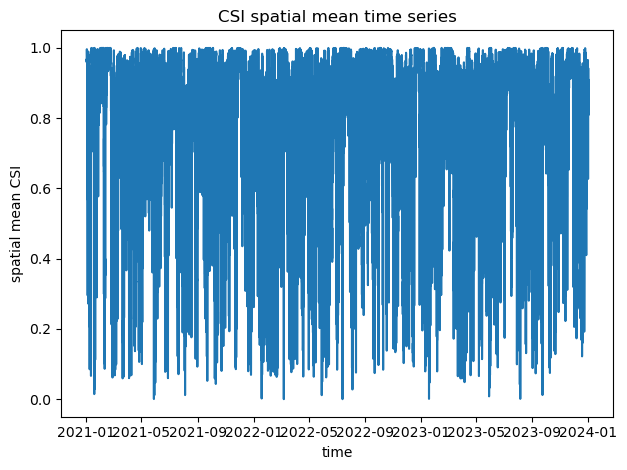

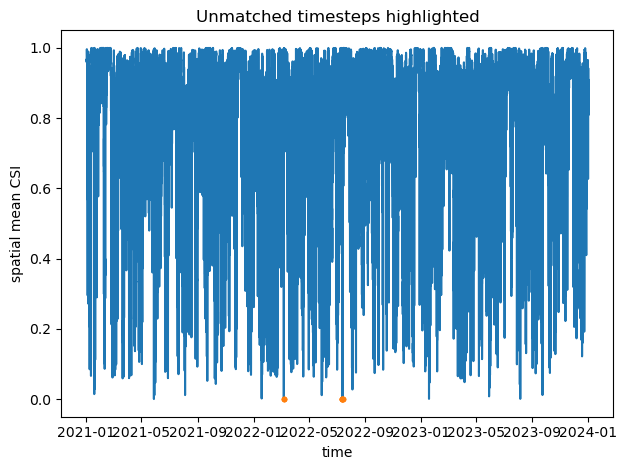

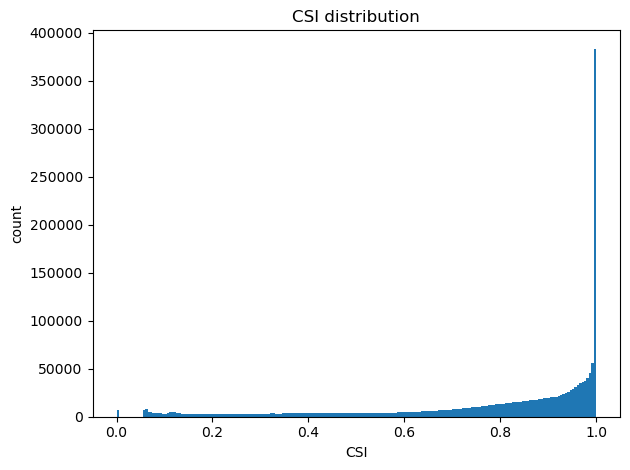

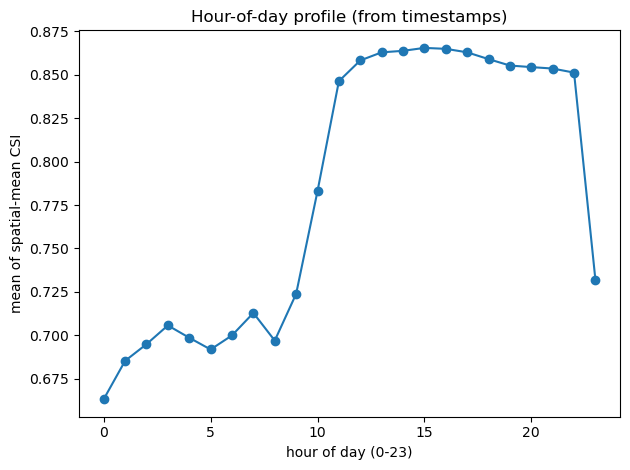

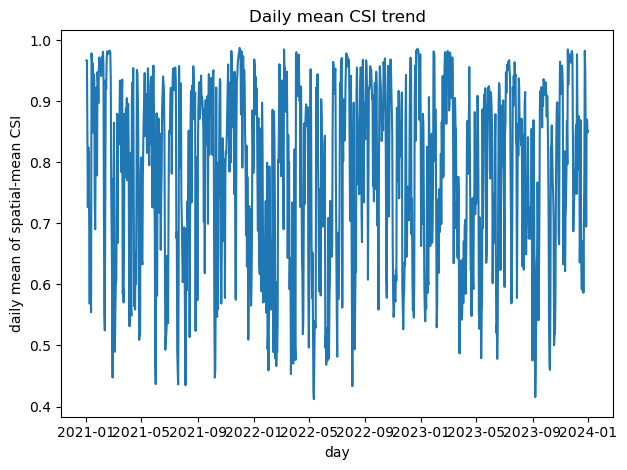

In [1]:
import numpy as np
import matplotlib.pyplot as plt

NPZ = "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz"

def to_dt64_ns(t):
    return np.asarray(t).astype("datetime64[ns]")

def analyze_csi_npz(npz_path=NPZ, show_examples=10, max_print_unmatched=30):
    z = np.load(npz_path, allow_pickle=True)
    keys = list(z.files)
    print("=== NPZ keys ===")
    print(keys)

    # --- load time + csi ---
    if "time" not in z.files:
        raise KeyError("npz must contain key 'time'")
    if "csi" not in z.files:
        raise KeyError("npz must contain key 'csi'")

    t = to_dt64_ns(z["time"])              # (T,)
    csi = np.asarray(z["csi"])             # (T,H,W) or (T,1,H,W) depending on your save
    if csi.ndim == 4 and csi.shape[1] == 1:
        csi = csi[:, 0, :, :]
    if csi.ndim != 3:
        raise ValueError(f"Expected csi shape (T,H,W). Got {csi.shape}")

    T, H, W = csi.shape
    print("\n=== Shapes ===")
    print("T,H,W =", (T, H, W))
    print("time range:", t[0], "->", t[-1])

    # --- time step diagnostics ---
    dt = np.diff(t).astype("timedelta64[m]").astype(int)  # minutes
    uniq, cnt = np.unique(dt, return_counts=True)
    order = np.argsort(cnt)[::-1]

    print("\n=== Time step stats (minutes) ===")
    print("unique dt count:", len(uniq))
    print("top dt values:")
    for i in order[:min(10, len(order))]:
        print(f"  dt={uniq[i]} min : {cnt[i]}")

    # check monotonic + duplicates
    non_inc = np.where(np.diff(t) <= np.timedelta64(0, "ns"))[0]
    if len(non_inc) > 0:
        print("\nWARNING: non-increasing or duplicate time stamps:", len(non_inc))
        print("first few indices:", non_inc[:show_examples])
        for i in non_inc[:min(show_examples, len(non_inc))]:
            print("  i", i, ":", t[i], "->", t[i+1])
    else:
        print("\nTime is strictly increasing.")

    # --- missing/unmatched diagnostics (if present) ---
    print("\n=== Matching / missing info (if present) ===")
    unmatched_time = None
    if "unmatched_time" in z.files:
        unmatched_time = to_dt64_ns(z["unmatched_time"])
        print("unmatched_time count:", len(unmatched_time))
        print("first few unmatched_time:", unmatched_time[:min(max_print_unmatched, len(unmatched_time))])
    elif "match_mode" in z.files:
        mm = np.asarray(z["match_mode"])
        miss = np.where(mm == "unmatched")[0]
        print("match_mode present. unmatched count:", len(miss))
        if "night_hour_idx" in z.files:
            nh = np.asarray(z["night_hour_idx"]).astype(int)
            ut_idx = nh[miss]
            unmatched_time = t[ut_idx]
            print("first few unmatched_time:", unmatched_time[:min(max_print_unmatched, len(unmatched_time))])
        else:
            print("night_hour_idx not found; cannot map unmatched to global time directly.")
    else:
        print("No unmatched info saved (unmatched_time / match_mode not found).")

    # --- basic CSI value stats ---
    print("\n=== CSI value stats ===")
    finite = np.isfinite(csi)
    n_finite = finite.sum()
    n_total = csi.size
    print("finite ratio:", n_finite / n_total)
    if n_finite == 0:
        raise ValueError("No finite CSI values found.")

    csi_f = csi[finite]
    print("min/max:", float(np.nanmin(csi_f)), float(np.nanmax(csi_f)))
    print("p01/p50/p99:", np.percentile(csi_f, [1, 50, 99]))

    # --- spatial mean time series ---
    csi_mean = np.nanmean(csi, axis=(1,2))   # (T,)
    csi_std  = np.nanstd(csi, axis=(1,2))    # (T,)

    # --- hour-of-day profile (UTC/local unknown; still useful) ---
    hours = t.astype("datetime64[h]").astype(int) % 24
    hod_mean = np.full(24, np.nan, dtype=float)
    hod_std  = np.full(24, np.nan, dtype=float)
    for h in range(24):
        sel = (hours == h)
        if np.any(sel):
            hod_mean[h] = np.nanmean(csi_mean[sel])
            hod_std[h]  = np.nanstd(csi_mean[sel])

    # --- daily mean series (coarse trend) ---
    days = t.astype("datetime64[D]")
    uday, inv = np.unique(days, return_inverse=True)
    daily_mean = np.full(len(uday), np.nan, dtype=float)
    for i in range(len(uday)):
        sel = (inv == i)
        daily_mean[i] = np.nanmean(csi_mean[sel])

    print("\n=== Summary ===")
    print("mean(csi_mean):", float(np.nanmean(csi_mean)))
    print("std(csi_mean) :", float(np.nanstd(csi_mean)))
    print("num NaN in csi_mean:", int(np.sum(~np.isfinite(csi_mean))))

    # --- plots ---
    # 1) mean CSI over time
    plt.figure()
    plt.plot(t, csi_mean)
    plt.xlabel("time")
    plt.ylabel("spatial mean CSI")
    plt.title("CSI spatial mean time series")
    plt.tight_layout()

    # mark unmatched times if available
    if unmatched_time is not None and len(unmatched_time) > 0:
        # find indices in global time via exact match
        # (unmatched_time should already be from global time or mapable)
        # safest: set membership with numpy isin
        mask_u = np.isin(t, unmatched_time)
        if np.any(mask_u):
            plt.figure()
            plt.plot(t, csi_mean)
            plt.plot(t[mask_u], csi_mean[mask_u], "o", markersize=3)
            plt.xlabel("time")
            plt.ylabel("spatial mean CSI")
            plt.title("Unmatched timesteps highlighted")
            plt.tight_layout()

    # 2) histogram of CSI
    plt.figure()
    # sample for speed if huge
    sample = csi_f
    if sample.size > 2_000_000:
        rng = np.random.default_rng(0)
        sample = rng.choice(sample, size=2_000_000, replace=False)
    plt.hist(sample, bins=200)
    plt.xlabel("CSI")
    plt.ylabel("count")
    plt.title("CSI distribution")
    plt.tight_layout()

    # 3) hour-of-day mean profile
    plt.figure()
    plt.plot(np.arange(24), hod_mean, marker="o")
    plt.xlabel("hour of day (0-23)")
    plt.ylabel("mean of spatial-mean CSI")
    plt.title("Hour-of-day profile (from timestamps)")
    plt.tight_layout()

    # 4) daily mean (trend)
    plt.figure()
    plt.plot(uday.astype("datetime64[ns]"), daily_mean)
    plt.xlabel("day")
    plt.ylabel("daily mean of spatial-mean CSI")
    plt.title("Daily mean CSI trend")
    plt.tight_layout()

    plt.show()

    return {
        "keys": keys,
        "T": T, "H": H, "W": W,
        "time": t,
        "dt_minutes_unique": (uniq, cnt),
        "csi_mean": csi_mean,
        "csi_std": csi_std,
        "unmatched_time": unmatched_time,
        "daily_days": uday,
        "daily_mean": daily_mean,
        "hod_mean": hod_mean,
        "hod_std": hod_std,
    }

out = analyze_csi_npz(NPZ)


In [2]:
import numpy as np

def to_dt64_ns(t):
    return np.asarray(t).astype("datetime64[ns]")

def pick_cams_hourly_raw_indices(cams_time_ns):
    t_m = cams_time_ns.astype("datetime64[m]")
    minutes = t_m.astype(np.int64)
    return np.where((minutes % 60) == 0)[0]

def compare_cams_hourly_vs_saved(
    cams_npz="Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    saved_npz="Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    start="2021-01-01T00:00",
    end="2023-12-31T23:59"
):
    cams = np.load(cams_npz, allow_pickle=True)
    t = to_dt64_ns(cams["time"])
    idx_h = pick_cams_hourly_raw_indices(t)
    t_h = t[idx_h]

    start_dt = np.datetime64(start).astype("datetime64[ns]")
    end_dt   = np.datetime64(end).astype("datetime64[ns]")
    keep = (t_h >= start_dt) & (t_h <= end_dt)
    t_h = t_h[keep]

    out = np.load(saved_npz, allow_pickle=True)
    t_s = to_dt64_ns(out["time"])

    print("cams hourly clipped:", len(t_h), t_h[0], "->", t_h[-1])
    print("saved:", len(t_s), t_s[0], "->", t_s[-1])
    if len(t_h) != len(t_s):
        print("LENGTH MISMATCH.")
        return False
    ok = np.all(t_h == t_s)
    print("time identical?", ok)
    if not ok:
        bad = np.where(t_h != t_s)[0]
        print("first 10 bad indices:", bad[:10])
        for i in bad[:10]:
            print("  i", i, "cams", t_h[i], "saved", t_s[i])
    return ok

compare_cams_hourly_vs_saved()


cams hourly clipped: 26269 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000
saved: 26269 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000
time identical? True


np.True_

In [3]:
import numpy as np

z = np.load("Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz", allow_pickle=True)
csi = z["csi"]
if csi.ndim == 4 and csi.shape[1] == 1:
    csi = csi[:,0]

x = csi.reshape(-1)
finite = np.isfinite(x)
x = x[finite]

print("total finite:", x.size)
print("exact zero ratio:", np.mean(x == 0.0))
print("|x|<1e-6 ratio :", np.mean(np.abs(x) < 1e-6))
print("|x|<1e-4 ratio :", np.mean(np.abs(x) < 1e-4))
print("min/max:", float(x.min()), float(x.max()))


total finite: 65672500
exact zero ratio: 0.0036733640412653697
|x|<1e-6 ratio : 0.0036733640412653697
|x|<1e-4 ratio : 0.0036733640412653697
min/max: 0.0 1.0047634840011597


In [4]:
import numpy as np

cams = np.load("Data/CAMS/ghi_grid2500_2ch_15mins.npz", allow_pickle=True)
cams_time = cams["time"].astype("datetime64[ns]")
cams_data = cams["data"]

# hourly raw indices (minute==0)
t_m = cams_time.astype("datetime64[m]")
idx_h = np.where((t_m.astype(np.int64) % 60) == 0)[0]

# clip 2021-2023 (跟你现在一致)
start = np.datetime64("2021-01-01T00:00").astype("datetime64[ns]")
end   = np.datetime64("2023-12-31T23:59").astype("datetime64[ns]")
keep = (cams_time[idx_h] >= start) & (cams_time[idx_h] <= end)
idx_h = idx_h[keep]

hourly = cams_data[idx_h]     # (Th,2,50,50)
ghi = hourly[:,0]
cs  = hourly[:,1]

night = np.all(cs == 0, axis=(1,2))     # 你定义的夜间
ghi_all0 = np.all(ghi == 0, axis=(1,2))

print("hourly samples:", len(idx_h))
print("night hours (cs all0):", int(night.sum()))
print("among night: ghi all0:", int(np.sum(night & ghi_all0)))
print("among night: ghi NOT all0:", int(np.sum(night & (~ghi_all0))))


hourly samples: 26269
night hours (cs all0): 12719
among night: ghi all0: 12719
among night: ghi NOT all0: 0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def to_dt64_ns(t):
    return np.asarray(t).astype("datetime64[ns]")

def plot_csi_24h(npz_path, start_time, key_time="time", key_csi="csi",
                vmin=0.0, vmax=1.2, show=True):
    """
    Plot 24 consecutive hourly CSI maps starting from start_time.
    start_time: str or np.datetime64, should match exactly an entry in time.
    """
    z = np.load(npz_path, allow_pickle=True)
    t = to_dt64_ns(z[key_time])
    csi = np.asarray(z[key_csi])
    if csi.ndim == 4 and csi.shape[1] == 1:
        csi = csi[:, 0]
    if csi.ndim != 3:
        raise ValueError(f"Expected csi (T,H,W). Got {csi.shape}")

    start_time = np.datetime64(start_time).astype("datetime64[ns]")
    idx = np.where(t == start_time)[0]
    if idx.size == 0:
        # 给你一个最近的整点提示
        # 这里不做模糊匹配，避免你误用
        raise ValueError(f"start_time not found exactly in time axis: {start_time}")

    i0 = int(idx[0])
    if i0 + 24 > len(t):
        raise ValueError("Not enough samples after start_time to plot 24 hours.")

    # grid layout: 6x4 = 24
    nrows, ncols = 6, 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 18), constrained_layout=True)

    last_im = None
    for k in range(24):
        r, c = divmod(k, ncols)
        ax = axes[r, c]
        img = csi[i0 + k]
        last_im = ax.imshow(img, vmin=vmin, vmax=vmax)
        ax.set_title(str(t[i0 + k]).replace("T", " ")[:16])
        ax.set_xticks([]); ax.set_yticks([])

    fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.6, label="CSI")
    if show:
        plt.show()
    return fig


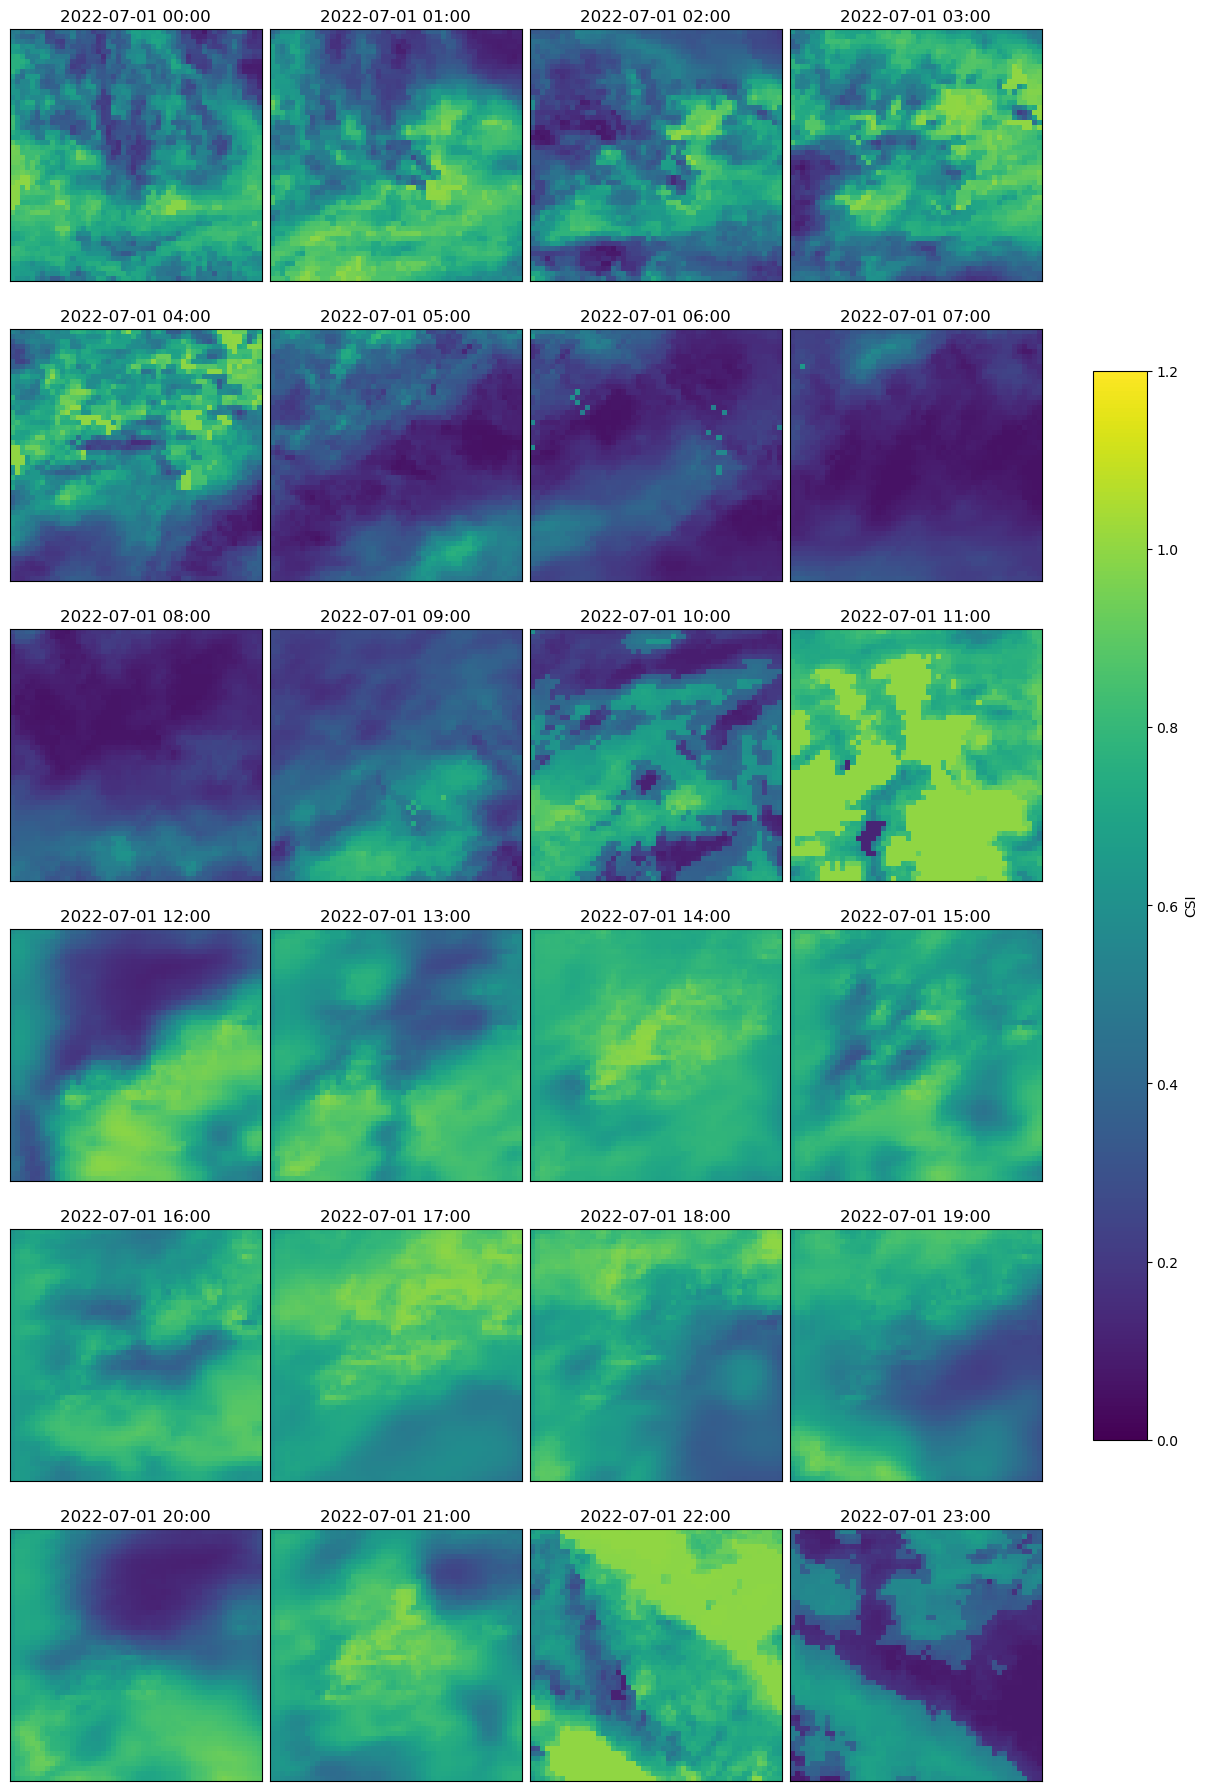

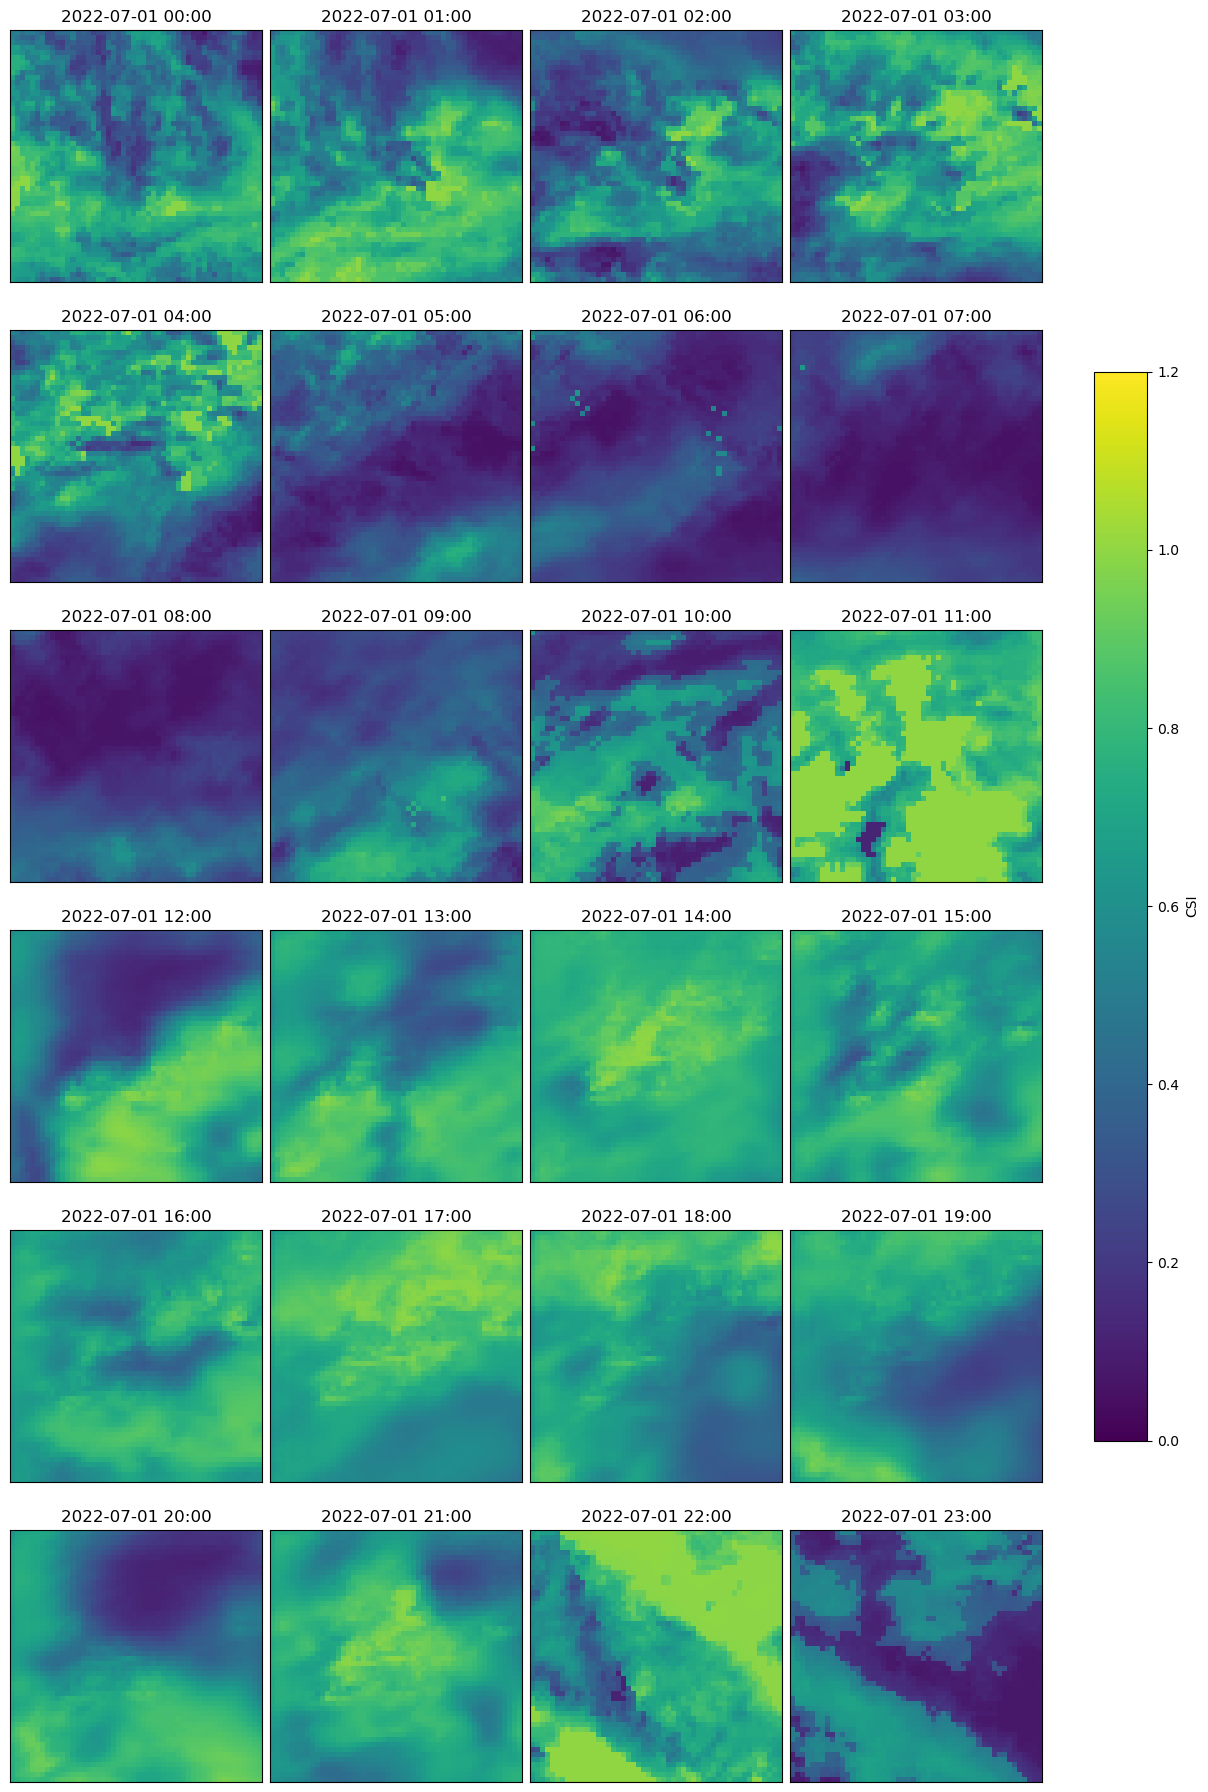

In [6]:
plot_csi_24h(
    "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    start_time="2022-07-01T00:00:00"
)


In [7]:
import numpy as np

def continuity_metrics_csi(npz_path, key_time="time", key_csi="csi",
                           eps=1e-8, top_k=50):
    """
    Compute hourly continuity metrics between consecutive CSI maps.
    Returns dict with arrays and prints top suspicious transitions.
    """
    z = np.load(npz_path, allow_pickle=True)
    t = to_dt64_ns(z[key_time])
    csi = np.asarray(z[key_csi])
    if csi.ndim == 4 and csi.shape[1] == 1:
        csi = csi[:, 0]
    if csi.ndim != 3:
        raise ValueError(f"Expected csi (T,H,W). Got {csi.shape}")

    T, H, W = csi.shape
    X = csi.reshape(T, -1)  # (T, P)

    # consecutive diffs
    d = X[1:] - X[:-1]  # (T-1, P)
    l1 = np.nanmean(np.abs(d), axis=1)
    l2 = np.sqrt(np.nanmean(d * d, axis=1))

    # correlation between maps t and t+1
    # corr = cov / (std1*std2)
    x0 = X[:-1]
    x1 = X[1:]
    m0 = np.nanmean(x0, axis=1, keepdims=True)
    m1 = np.nanmean(x1, axis=1, keepdims=True)
    v0 = x0 - m0
    v1 = x1 - m1
    cov = np.nanmean(v0 * v1, axis=1)
    s0 = np.sqrt(np.nanmean(v0 * v0, axis=1)) + eps
    s1 = np.sqrt(np.nanmean(v1 * v1, axis=1)) + eps
    corr = cov / (s0 * s1)

    # robust z-score (median/MAD) to detect jumps
    def robust_z(x):
        med = np.nanmedian(x)
        mad = np.nanmedian(np.abs(x - med)) + eps
        return (x - med) / (1.4826 * mad)

    z_l2 = robust_z(l2)
    z_l1 = robust_z(l1)
    z_corr = robust_z(-corr)  # corr低 => 可疑，所以取负

    jump_score = 0.5 * z_l2 + 0.3 * z_l1 + 0.2 * z_corr

    # classify transitions if metadata exists
    trans_type = np.array(["unknown"] * (T - 1), dtype=object)
    if "night_hour_idx" in z.files and "matched_mask" in z.files:
        night_hour_idx = z["night_hour_idx"].astype(int)
        matched = z["matched_mask"].astype(bool)

        is_night = np.zeros(T, dtype=bool)
        is_night[night_hour_idx] = True
        is_replaced_night = np.zeros(T, dtype=bool)
        is_replaced_night[night_hour_idx[matched]] = True
        is_unmatched_night = np.zeros(T, dtype=bool)
        is_unmatched_night[night_hour_idx[~matched]] = True

        for i in range(T - 1):
            a = "day" if not is_night[i] else ("night_replaced" if is_replaced_night[i] else "night_unmatched")
            b = "day" if not is_night[i+1] else ("night_replaced" if is_replaced_night[i+1] else "night_unmatched")
            trans_type[i] = f"{a} -> {b}"

    # print top suspicious transitions
    idx_sorted = np.argsort(jump_score)[::-1]
    print("=== Top suspicious hourly transitions (by jump_score) ===")
    for k in idx_sorted[:min(top_k, len(idx_sorted))]:
        print(f"[{k:5d}] {t[k]} -> {t[k+1]}  "
              f"jump={jump_score[k]:.2f}  l2={l2[k]:.4f}  l1={l1[k]:.4f}  corr={corr[k]:.3f}  type={trans_type[k]}")

    return {
        "time": t,
        "l1": l1,
        "l2": l2,
        "corr": corr,
        "jump_score": jump_score,
        "trans_type": trans_type,
        "top_idx": idx_sorted[:min(top_k, len(idx_sorted))],
    }


In [8]:
m = continuity_metrics_csi(
    "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    top_k=50
)


=== Top suspicious hourly transitions (by jump_score) ===
[17926] 2023-01-18T09:00:00.000000000 -> 2023-01-18T10:00:00.000000000  jump=8.17  l2=0.9951  l1=0.9943  corr=0.005  type=day -> day
[13392] 2022-07-13T11:00:00.000000000 -> 2022-07-13T12:00:00.000000000  jump=8.17  l2=0.9942  l1=0.9937  corr=0.000  type=day -> night_unmatched
[17927] 2023-01-18T10:00:00.000000000 -> 2023-01-18T11:00:00.000000000  jump=8.06  l2=0.9812  l1=0.9807  corr=-0.015  type=day -> night_replaced
[10323] 2022-03-07T14:00:00.000000000 -> 2022-03-07T15:00:00.000000000  jump=8.03  l2=0.9789  l1=0.9787  corr=0.000  type=night_replaced -> night_unmatched
[22703] 2023-08-05T10:00:00.000000000 -> 2023-08-05T11:00:00.000000000  jump=8.02  l2=0.9790  l1=0.9777  corr=0.015  type=day -> day
[10327] 2022-03-07T18:00:00.000000000 -> 2022-03-07T19:00:00.000000000  jump=8.01  l2=0.9761  l1=0.9758  corr=0.000  type=night_unmatched -> night_replaced
[  407] 2021-01-18T10:00:00.000000000 -> 2021-01-18T11:00:00.000000000  ju

In [9]:
import numpy as np

def summarize_transition_scores(metrics, group_map=None, print_top_each=0):
    """
    metrics: dict returned by continuity_metrics_csi()
    group_map: optional dict to merge transition labels into your desired buckets
               e.g. {"day -> day": "day->day", "night_replaced -> night_replaced": "nightR->nightR", ...}
    print_top_each: print top-k suspicious transitions in each group (0 disables)
    """
    t = metrics["time"]
    jump = metrics["jump_score"]
    l2 = metrics["l2"]
    corr = metrics["corr"]
    typ = metrics["trans_type"]

    if group_map is None:
        # default: keep original labels
        groups = typ
    else:
        groups = np.array([group_map.get(x, "other") for x in typ], dtype=object)

    # helper stats
    def stats(x):
        x = x[np.isfinite(x)]
        if x.size == 0:
            return None
        return {
            "N": int(x.size),
            "mean": float(np.mean(x)),
            "median": float(np.median(x)),
            "p90": float(np.quantile(x, 0.90)),
            "p99": float(np.quantile(x, 0.99)),
        }

    uniq = sorted(set(groups.tolist()))
    out = {}

    print("=== Overall continuity score by transition group ===")
    for g in uniq:
        idx = np.where(groups == g)[0]
        if idx.size == 0:
            continue

        sj = stats(jump[idx])
        sl2 = stats(l2[idx])
        sc = stats(corr[idx])

        out[g] = {"jump": sj, "l2": sl2, "corr": sc}

        print(f"\n[{g}]")
        print(f"  N={sj['N']}")
        print(f"  jump   mean={sj['mean']:.3f}  med={sj['median']:.3f}  p90={sj['p90']:.3f}  p99={sj['p99']:.3f}")
        print(f"  l2     mean={sl2['mean']:.3f}  med={sl2['median']:.3f}  p90={sl2['p90']:.3f}  p99={sl2['p99']:.3f}")
        print(f"  corr   mean={sc['mean']:.3f}  med={sc['median']:.3f}  p10={float(np.quantile(corr[idx],0.10)):.3f}  p01={float(np.quantile(corr[idx],0.01)):.3f}")

        if print_top_each > 0:
            # most suspicious in this group: highest jump
            k = min(print_top_each, idx.size)
            top = idx[np.argsort(jump[idx])[::-1][:k]]
            print("  top transitions:")
            for i in top:
                print(f"    [{i:5d}] {t[i]} -> {t[i+1]}  jump={jump[i]:.2f} l2={l2[i]:.3f} corr={corr[i]:.3f}")

    return out


In [10]:
bucket_map = {
    "day -> day": "day->day",
    "night_replaced -> night_replaced": "nightR->nightR",
    "day -> night_replaced": "day->nightR",
    "night_replaced -> day": "nightR->day",
}

# 其他情况先都归到 other
scores = summarize_transition_scores(m, group_map=bucket_map)


=== Overall continuity score by transition group ===

[day->day]
  N=12455
  jump   mean=0.483  med=0.374  p90=1.649  p99=3.691
  l2     mean=0.178  med=0.167  p90=0.306  p99=0.525
  corr   mean=0.430  med=0.444  p10=0.090  p01=-0.160

[day->nightR]
  N=1093
  jump   mean=1.509  med=0.969  p90=4.243  p99=7.186
  l2     mean=0.269  med=0.211  p90=0.574  p99=0.892
  corr   mean=0.106  med=0.089  p10=-0.161  p01=-0.453

[nightR->day]
  N=1094
  jump   mean=1.603  med=1.226  p90=3.965  p99=6.400
  l2     mean=0.284  med=0.248  p90=0.551  p99=0.835
  corr   mean=0.101  med=0.070  p10=-0.109  p01=-0.373

[nightR->nightR]
  N=11610
  jump   mean=-0.329  med=-0.395  p90=0.539  p99=1.482
  l2     mean=0.086  med=0.077  p90=0.172  p99=0.267
  corr   mean=0.598  med=0.640  p10=0.183  p01=-0.206

[other]
  N=16
  jump   mean=1.524  med=-0.643  p90=8.021  p99=8.148
  l2     mean=0.245  med=0.000  p90=0.977  p99=0.992
  corr   mean=0.000  med=0.000  p10=0.000  p01=0.000


In [11]:
def overall_score_from_npz(npz_path, top_k=0):
    m = continuity_metrics_csi(npz_path, top_k=0)  # 不打印 top suspicious
    bucket_map = {
        "day -> day": "day->day",
        "night_replaced -> night_replaced": "nightR->nightR",
        "day -> night_replaced": "day->nightR",
        "night_replaced -> day": "nightR->day",
    }
    return summarize_transition_scores(m, group_map=bucket_map, print_top_each=top_k)

scores = overall_score_from_npz("Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz", top_k=5)


=== Top suspicious hourly transitions (by jump_score) ===
=== Overall continuity score by transition group ===

[day->day]
  N=12455
  jump   mean=0.483  med=0.374  p90=1.649  p99=3.691
  l2     mean=0.178  med=0.167  p90=0.306  p99=0.525
  corr   mean=0.430  med=0.444  p10=0.090  p01=-0.160
  top transitions:
    [17926] 2023-01-18T09:00:00.000000000 -> 2023-01-18T10:00:00.000000000  jump=8.17 l2=0.995 corr=0.005
    [22703] 2023-08-05T10:00:00.000000000 -> 2023-08-05T11:00:00.000000000  jump=8.02 l2=0.979 corr=0.015
    [ 3527] 2021-05-28T10:00:00.000000000 -> 2021-05-28T11:00:00.000000000  jump=7.87 l2=0.963 corr=0.011
    [12311] 2022-05-29T10:00:00.000000000 -> 2022-05-29T11:00:00.000000000  jump=7.80 l2=0.947 corr=-0.148
    [  406] 2021-01-18T09:00:00.000000000 -> 2021-01-18T10:00:00.000000000  jump=7.60 l2=0.926 corr=-0.125

[day->nightR]
  N=1093
  jump   mean=1.509  med=0.969  p90=4.243  p99=7.186
  l2     mean=0.269  med=0.211  p90=0.574  p99=0.892
  corr   mean=0.106  med=0

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def inspect_top_jumps(npz_path, metrics, top_k=10,
                      key_time="time", key_csi="csi",
                      vmin=0.0, vmax=1.2,
                      diff_vmax=1.0):
    """
    npz_path: your saved CSI npz
    metrics: output dict from continuity_metrics_csi()
    top_k: how many largest jumps to inspect
    """
    z = np.load(npz_path, allow_pickle=True)
    t = np.asarray(z[key_time]).astype("datetime64[ns]")
    csi = np.asarray(z[key_csi])
    if csi.ndim == 4 and csi.shape[1] == 1:
        csi = csi[:, 0]
    if csi.ndim != 3:
        raise ValueError(f"Expected csi (T,H,W). Got {csi.shape}")

    jump = metrics["jump_score"]
    l2 = metrics["l2"]
    l1 = metrics["l1"]
    corr = metrics["corr"]
    typ = metrics["trans_type"]

    idx_sorted = np.argsort(jump)[::-1]
    top = idx_sorted[:min(top_k, len(idx_sorted))]

    def stat_img(img):
        x = img.reshape(-1)
        nan_ratio = np.mean(~np.isfinite(x))
        x = x[np.isfinite(x)]
        return {
            "nan_ratio": float(nan_ratio),
            "min": float(np.min(x)) if x.size else np.nan,
            "max": float(np.max(x)) if x.size else np.nan,
            "mean": float(np.mean(x)) if x.size else np.nan,
            "std": float(np.std(x)) if x.size else np.nan,
        }

    for i in top:
        A = csi[i]
        B = csi[i+1]
        D = B - A

        sa, sb, sd = stat_img(A), stat_img(B), stat_img(D)

        print("\n" + "="*90)
        print(f"[{i}] {t[i]} -> {t[i+1]}   type={typ[i]}")
        print(f"  jump={jump[i]:.2f}  l2={l2[i]:.4f}  l1={l1[i]:.4f}  corr={corr[i]:.3f}")
        print(f"  A stats: nan={sa['nan_ratio']:.4f} min={sa['min']:.3f} max={sa['max']:.3f} mean={sa['mean']:.3f} std={sa['std']:.3f}")
        print(f"  B stats: nan={sb['nan_ratio']:.4f} min={sb['min']:.3f} max={sb['max']:.3f} mean={sb['mean']:.3f} std={sb['std']:.3f}")
        print(f"  D stats: nan={sd['nan_ratio']:.4f} min={sd['min']:.3f} max={sd['max']:.3f} mean={sd['mean']:.3f} std={sd['std']:.3f}")

        # plot
        fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
        im0 = axes[0].imshow(A, vmin=vmin, vmax=vmax)
        axes[0].set_title(str(t[i]).replace("T"," ")[:16])
        axes[0].set_xticks([]); axes[0].set_yticks([])
        plt.colorbar(im0, ax=axes[0], fraction=0.046)

        im1 = axes[1].imshow(B, vmin=vmin, vmax=vmax)
        axes[1].set_title(str(t[i+1]).replace("T"," ")[:16])
        axes[1].set_xticks([]); axes[1].set_yticks([])
        plt.colorbar(im1, ax=axes[1], fraction=0.046)

        # diff plot (centered)
        vmaxd = diff_vmax
        im2 = axes[2].imshow(D, vmin=-vmaxd, vmax=vmaxd)
        axes[2].set_title("diff (t+1 - t)")
        axes[2].set_xticks([]); axes[2].set_yticks([])
        plt.colorbar(im2, ax=axes[2], fraction=0.046)

        plt.show()


In [ ]:
# 7-13 那一天不好

=== Top suspicious hourly transitions (by jump_score) ===

[17926] 2023-01-18T09:00:00.000000000 -> 2023-01-18T10:00:00.000000000   type=day -> day
  jump=8.17  l2=0.9951  l1=0.9943  corr=0.005
  A stats: nan=0.0000 min=0.652 max=1.000 mean=0.995 std=0.029
  B stats: nan=0.0000 min=0.000 max=1.000 mean=0.001 std=0.028
  D stats: nan=0.0000 min=-1.000 max=0.000 mean=-0.994 std=0.040


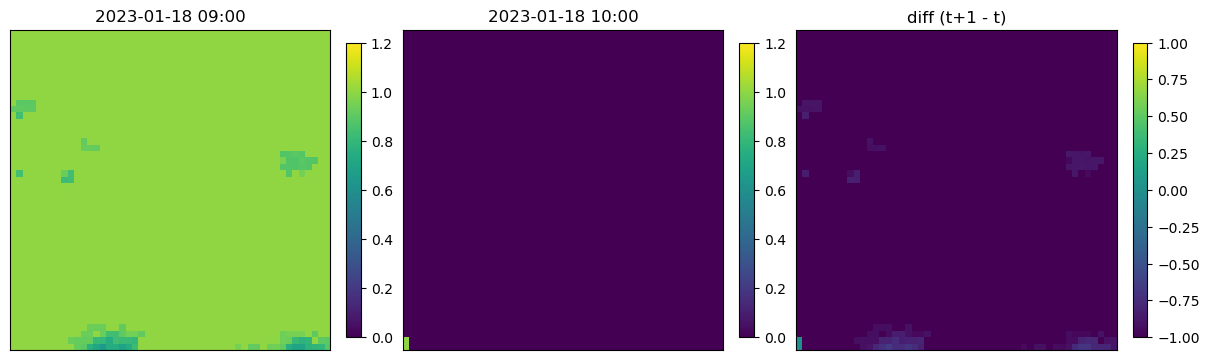


[13392] 2022-07-13T11:00:00.000000000 -> 2022-07-13T12:00:00.000000000   type=day -> night_unmatched
  jump=8.17  l2=0.9942  l1=0.9937  corr=0.000
  A stats: nan=0.0000 min=0.683 max=1.000 mean=0.994 std=0.032
  B stats: nan=0.0000 min=0.000 max=0.000 mean=0.000 std=0.000
  D stats: nan=0.0000 min=-1.000 max=-0.683 mean=-0.994 std=0.032


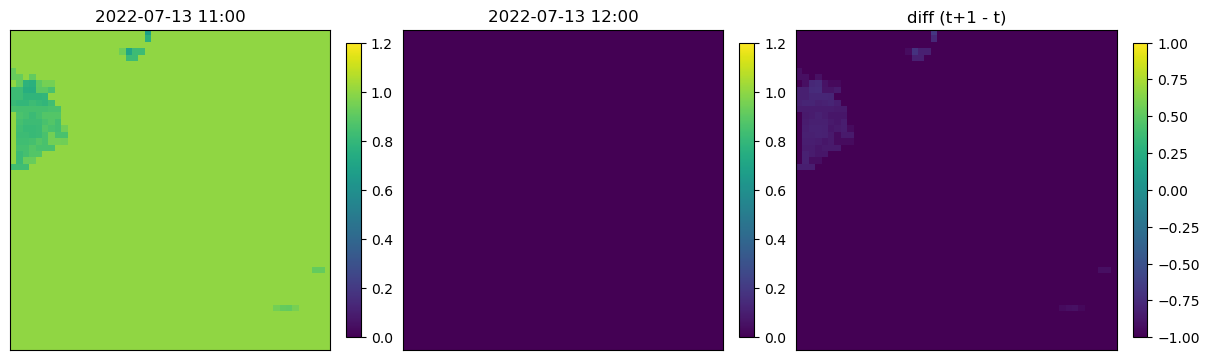


[17927] 2023-01-18T10:00:00.000000000 -> 2023-01-18T11:00:00.000000000   type=day -> night_replaced
  jump=8.06  l2=0.9812  l1=0.9807  corr=-0.015
  A stats: nan=0.0000 min=0.000 max=1.000 mean=0.001 std=0.028
  B stats: nan=0.0000 min=0.872 max=1.000 mean=0.981 std=0.019
  D stats: nan=0.0000 min=-0.030 max=1.000 mean=0.981 std=0.035


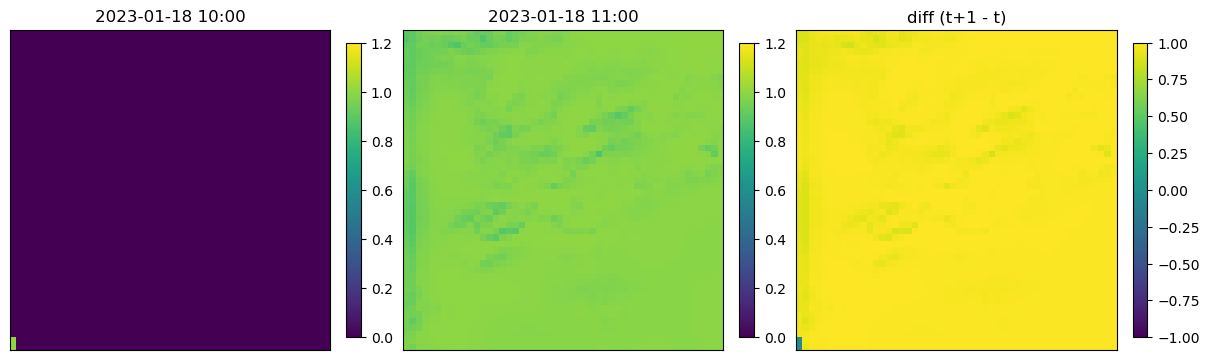


[10323] 2022-03-07T14:00:00.000000000 -> 2022-03-07T15:00:00.000000000   type=night_replaced -> night_unmatched
  jump=8.03  l2=0.9789  l1=0.9787  corr=0.000
  A stats: nan=0.0000 min=0.878 max=1.000 mean=0.979 std=0.019
  B stats: nan=0.0000 min=0.000 max=0.000 mean=0.000 std=0.000
  D stats: nan=0.0000 min=-1.000 max=-0.878 mean=-0.979 std=0.019


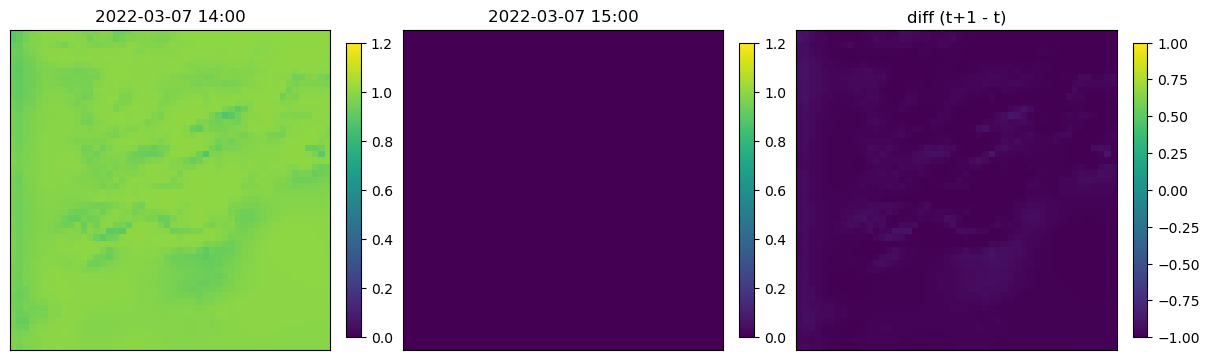


[22703] 2023-08-05T10:00:00.000000000 -> 2023-08-05T11:00:00.000000000   type=day -> day
  jump=8.02  l2=0.9790  l1=0.9777  corr=0.015
  A stats: nan=0.0000 min=0.576 max=1.000 mean=0.978 std=0.042
  B stats: nan=0.0000 min=0.000 max=1.000 mean=0.001 std=0.028
  D stats: nan=0.0000 min=-1.000 max=0.000 mean=-0.978 std=0.050


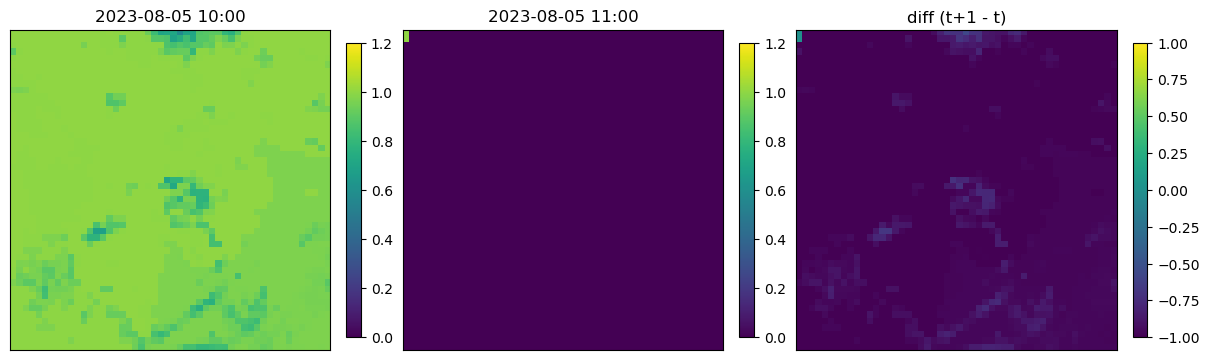


[10327] 2022-03-07T18:00:00.000000000 -> 2022-03-07T19:00:00.000000000   type=night_unmatched -> night_replaced
  jump=8.01  l2=0.9761  l1=0.9758  corr=0.000
  A stats: nan=0.0000 min=0.000 max=0.000 mean=0.000 std=0.000
  B stats: nan=0.0000 min=0.864 max=1.000 mean=0.976 std=0.024
  D stats: nan=0.0000 min=0.864 max=1.000 mean=0.976 std=0.024


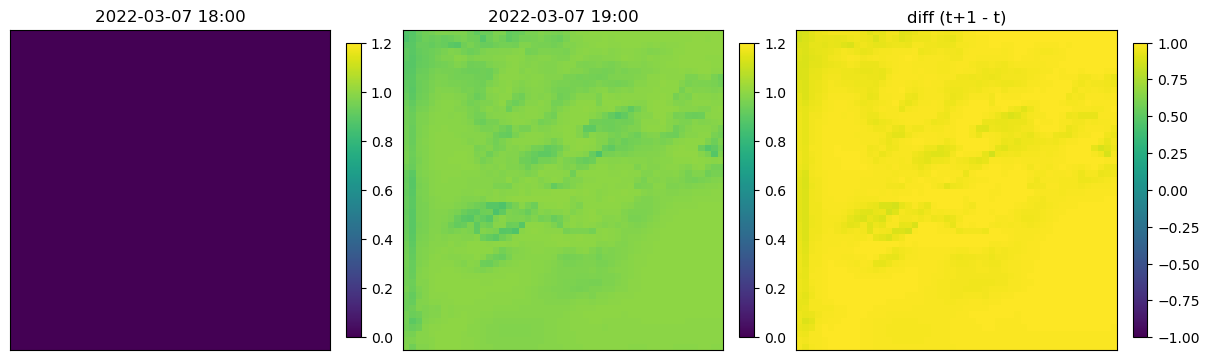


[407] 2021-01-18T10:00:00.000000000 -> 2021-01-18T11:00:00.000000000   type=day -> night_replaced
  jump=7.99  l2=0.9641  l1=0.9571  corr=-0.183
  A stats: nan=0.0000 min=0.000 max=1.000 mean=0.014 std=0.109
  B stats: nan=0.0000 min=0.838 max=1.000 mean=0.971 std=0.025
  D stats: nan=0.0000 min=-0.042 max=1.000 mean=0.957 std=0.116


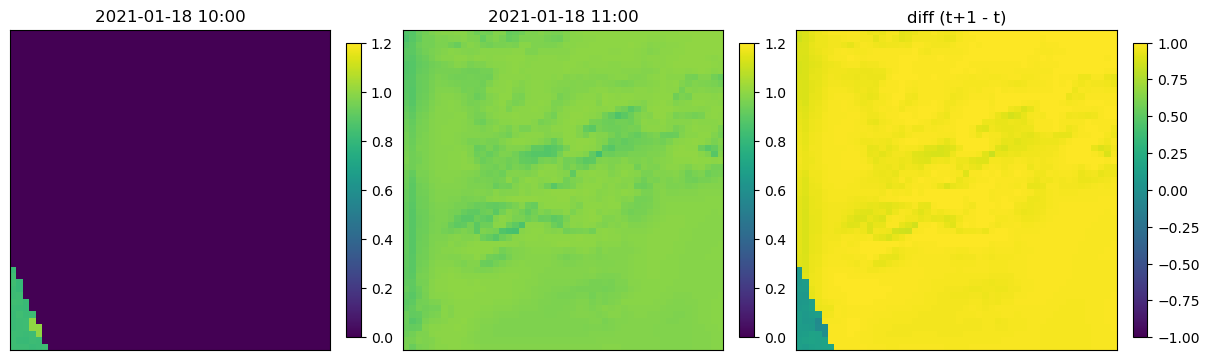


[23866] 2023-09-22T21:00:00.000000000 -> 2023-09-22T22:00:00.000000000   type=night_replaced -> day
  jump=7.92  l2=0.9653  l1=0.9601  corr=-0.040
  A stats: nan=0.0000 min=0.756 max=1.000 mean=0.972 std=0.028
  B stats: nan=0.0000 min=0.000 max=1.000 mean=0.012 std=0.098
  D stats: nan=0.0000 min=-1.000 max=0.029 mean=-0.960 std=0.103


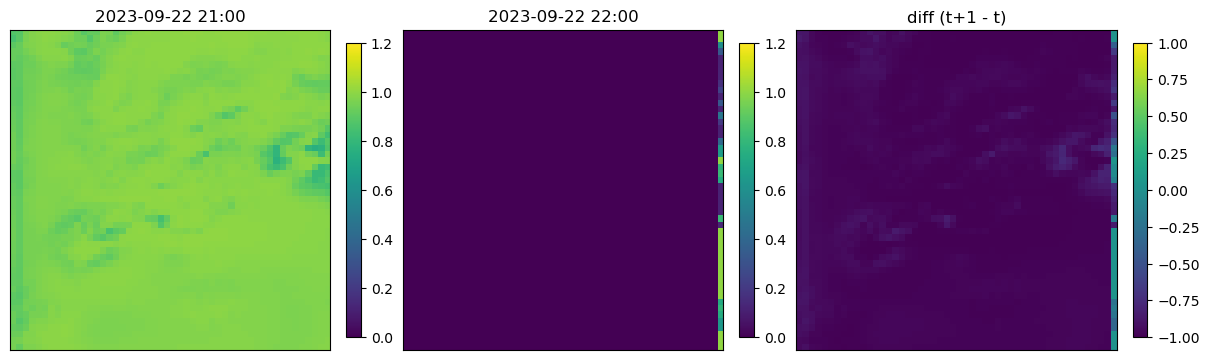


[3528] 2021-05-28T11:00:00.000000000 -> 2021-05-28T12:00:00.000000000   type=day -> night_replaced
  jump=7.89  l2=0.9585  l1=0.9578  corr=-0.063
  A stats: nan=0.0000 min=0.000 max=1.000 mean=0.000 std=0.020
  B stats: nan=0.0000 min=0.824 max=1.000 mean=0.958 std=0.033
  D stats: nan=0.0000 min=-0.144 max=1.000 mean=0.958 std=0.039


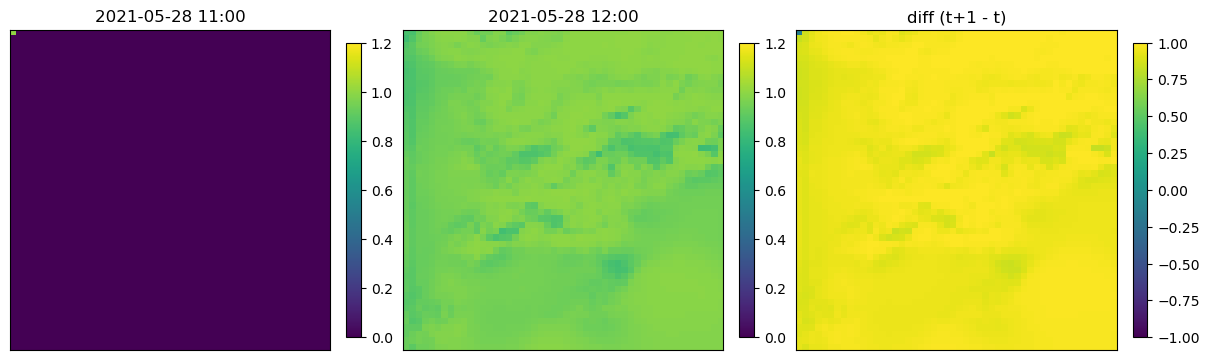


[13402] 2022-07-13T21:00:00.000000000 -> 2022-07-13T22:00:00.000000000   type=night_unmatched -> day
  jump=7.89  l2=0.9661  l1=0.9574  corr=0.000
  A stats: nan=0.0000 min=0.000 max=0.000 mean=0.000 std=0.000
  B stats: nan=0.0000 min=0.119 max=1.000 mean=0.957 std=0.129
  D stats: nan=0.0000 min=0.119 max=1.000 mean=0.957 std=0.129


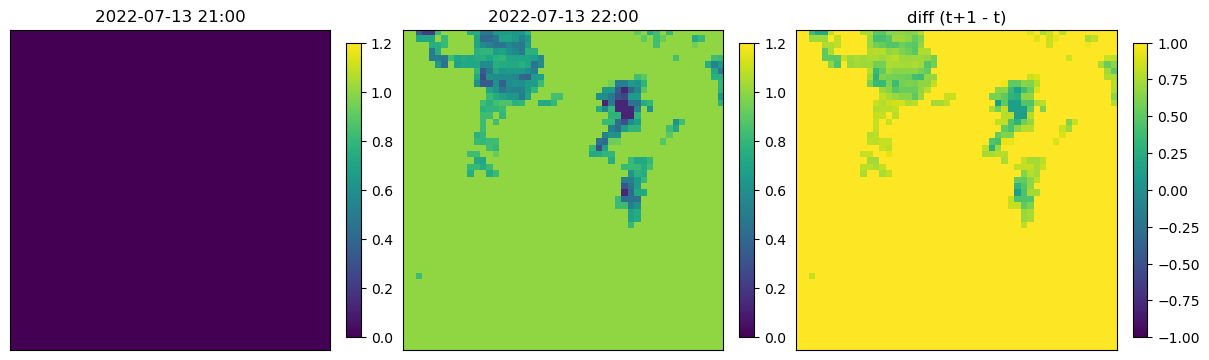

In [13]:
npz_path = "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz"

m = continuity_metrics_csi(npz_path, top_k=0)   # 先算指标（别打印top）
inspect_top_jumps(npz_path, m, top_k=10, vmin=0.0, vmax=1.2, diff_vmax=1.0)


In [34]:
def inspect_top_jumps_by_type(npz_path, metrics, want_type="day -> day", top_k=20, **kwargs):
    jump = metrics["jump_score"]
    typ = metrics["trans_type"]
    idx = np.where(typ == want_type)[0]
    if idx.size == 0:
        print("No transitions for type:", want_type)
        return
    sub = idx[np.argsort(jump[idx])[::-1]]
    metrics_sub = dict(metrics)
    # hack: keep arrays, but we will pass a modified sorting by temporarily reassigning jump
    # easiest: just inspect manually
    z = np.load(npz_path, allow_pickle=True)
    t = np.asarray(z["time"]).astype("datetime64[ns]")
    print(f"Top {min(top_k, len(sub))} transitions for type='{want_type}':")
    for k in sub[:min(top_k, len(sub))]:
        print(f"  [{k}] {t[k]} -> {t[k+1]}  jump={jump[k]:.2f} l2={metrics['l2'][k]:.3f} corr={metrics['corr'][k]:.3f}")
    # then call the generic inspector on those indices if you want plots


In [15]:
import numpy as np
import torch
from torch.utils.data import Dataset

# -----------------------
# time utilities
# -----------------------
def to_dt64_ns(t, int_unit="s"):
    """
    Accept datetime64 or integer epoch.
    int_unit: "s" or "ms" or "us" or "ns"
    """
    t = np.asarray(t)
    if np.issubdtype(t.dtype, np.datetime64):
        return t.astype("datetime64[ns]")

    if np.issubdtype(t.dtype, np.integer):
        # interpret as epoch in int_unit
        unit = np.timedelta64(1, int_unit)
        return (t.astype("int64") * unit).astype("datetime64[ns]")

    # strings
    return t.astype("datetime64[ns]")

def utc_to_hkt(t_ns):
    return t_ns + np.timedelta64(8, "h")

def build_continuous_hourly_axis(time_hkt_ns):
    """
    Build continuous hourly time axis in HKT.
    Returns:
      full_time_hkt_ns: (Tfull,)
      idx_map: (Tfull,) map to original index (first occurrence) or -1 if missing
      valid:   (Tfull,) 1 if exists else 0
    """
    t = np.asarray(time_hkt_ns).astype("datetime64[h]")
    t0, t1 = t[0], t[-1]
    full = np.arange(t0, t1 + np.timedelta64(1, "h"), np.timedelta64(1, "h")).astype("datetime64[h]")
    full_ns = full.astype("datetime64[ns]")

    # map hour -> first index
    m = {}
    for i, ti in enumerate(t):
        if ti not in m:
            m[ti] = i

    idx_map = np.array([m.get(tt, -1) for tt in full], dtype=np.int64)
    valid = (idx_map >= 0).astype(np.uint8)
    return full_ns, idx_map, valid

def make_window_starts(full_time_hkt_ns, valid_mask, in_len, out_len,
                       mode="rolling", anchor_hour=10, stride=1):
    """
    mode:
      - "rolling": all possible starts with given stride
      - "fixed_time": only windows whose *input end time* falls at anchor_hour (HKT)
                     i.e., full_time[s+in_len-1].hour == anchor_hour
    """
    T = len(full_time_hkt_ns)
    starts = []
    for s in range(0, T - (in_len + out_len) + 1, stride):
        if mode == "fixed_time":
            end_t = full_time_hkt_ns[s + in_len - 1].astype("datetime64[h]")
            hour = int((end_t.astype("datetime64[h]").astype("datetime64[m]").astype("int64") % (24*60)) // 60)
            if hour != int(anchor_hour):
                continue
        # NOTE: we keep windows even if missing exists; mask will handle in loss
        starts.append(s)
    return np.array(starts, dtype=np.int64)

# -----------------------
# Dataset
# -----------------------
class CSIMaskedSeq2SeqDataset(Dataset):
    """
    Returns:
      x: (in_len, 1, H, W)
      y: (out_len, 1, H, W)
      mask_y: (out_len,)  float32  (1 valid hour else 0)
      time_x_hkt: (in_len,) datetime64[ns]  (optional)
      time_y_hkt: (out_len,) datetime64[ns] (optional)
    """
    def __init__(self,
                 npz_path,
                 in_len=24,
                 out_len=6,
                 mode="rolling",          # "rolling" or "fixed_time"
                 anchor_hour=10,          # only used for fixed_time
                 stride=1,                # rolling stride
                 time_key="time",
                 csi_key="csi",
                 time_is_utc=True,
                 int_time_unit="s",
                 fill_value=0.0,
                 clip=(0.0, 1.2),
                 return_times=False):
        z = np.load(npz_path, allow_pickle=True)
        time_raw = z[time_key]
        csi = np.asarray(z[csi_key])

        if csi.ndim == 4 and csi.shape[1] == 1:
            csi = csi[:, 0]  # (T,H,W)
        if csi.ndim != 3:
            raise ValueError(f"Expected csi (T,H,W), got {csi.shape}")

        time_ns = to_dt64_ns(time_raw, int_unit=int_time_unit)
        time_hkt = utc_to_hkt(time_ns) if time_is_utc else time_ns

        # build continuous hourly axis in HKT
        full_time_hkt, idx_map, valid = build_continuous_hourly_axis(time_hkt)

        Tfull = len(full_time_hkt)
        H, W = csi.shape[-2], csi.shape[-1]

        # materialize CSI on continuous axis (fill missing)
        csi_full = np.full((Tfull, H, W), fill_value, dtype=np.float32)
        ok = idx_map >= 0
        csi_full[ok] = csi[idx_map[ok]].astype(np.float32)

        # optional clip (recommended for stability)
        if clip is not None:
            lo, hi = clip
            csi_full = np.clip(csi_full, lo, hi)

        # handle NaN inside existing frames: convert NaN -> fill_value and keep a pixel mask if you want later
        nan_mask = ~np.isfinite(csi_full)
        if np.any(nan_mask):
            csi_full[nan_mask] = fill_value

        starts = make_window_starts(full_time_hkt, valid, in_len, out_len,
                                    mode=mode, anchor_hour=anchor_hour, stride=stride)

        self.full_time_hkt = full_time_hkt
        self.valid = valid.astype(np.float32)
        self.csi_full = csi_full  # float32 (Tfull,H,W)
        self.starts = starts
        self.in_len = in_len
        self.out_len = out_len
        self.return_times = return_times

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = int(self.starts[i])
        a = s
        b = s + self.in_len
        c = b + self.out_len

        x = self.csi_full[a:b]               # (in_len,H,W)
        y = self.csi_full[b:c]               # (out_len,H,W)
        mask_y = self.valid[b:c]             # (out_len,)

        # add channel dim
        x = torch.from_numpy(x[:, None, :, :])          # (in_len,1,H,W)
        y = torch.from_numpy(y[:, None, :, :])          # (out_len,1,H,W)
        mask_y = torch.from_numpy(mask_y.astype(np.float32))  # (out_len,)

        if self.return_times:
            time_x = self.full_time_hkt[a:b]
            time_y = self.full_time_hkt[b:c]
            return x, y, mask_y, time_x, time_y

        return x, y, mask_y


In [16]:
def masked_mse(y_hat, y_true, mask_y, eps=1e-6):
    """
    y_hat,y_true: (B, out_len, 1, H, W)
    mask_y: (B, out_len)  0/1
    """
    mask = mask_y[:, :, None, None, None]  # broadcast
    diff2 = (y_hat - y_true) ** 2
    num = (diff2 * mask).sum()
    den = mask.sum() * y_true.shape[-2] * y_true.shape[-1] + eps
    return num / den


In [21]:
train_ds = CSIMaskedSeq2SeqDataset(
    "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    in_len=12, out_len=12,
    mode="rolling", stride=1,
    time_is_utc=True,   # 你的 time 是 UTC 就 True
    return_times=False
)


In [22]:
train_ds_fixed = CSIMaskedSeq2SeqDataset(
    "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz",
    in_len=12, out_len=12,
    mode="fixed_time", anchor_hour=10,
    time_is_utc=True
)


In [24]:
@torch.no_grad()
def persistence_last_frame(x, out_len):
    """
    x: (B, in_len, 1, H, W)
    return y_hat: (B, out_len, 1, H, W)
    """
    last = x[:, -1:, :, :, :]                 # (B,1,1,H,W)
    y_hat = last.repeat(1, out_len, 1, 1, 1)  # (B,out_len,1,H,W)
    return y_hat
@torch.no_grad()
def persistence_12_to_12_diurnal(x, out_len):
    """
    Diurnal persistence: y_hat[t+h] = x[t+h-24]
    For in_len=24, this is simply taking the first out_len frames of input.
    x: (B, in_len, 1, H, W)
    return: (B, out_len, 1, H, W)
    """
    if out_len > x.shape[1]:
        raise ValueError(f"out_len={out_len} > in_len={x.shape[1]} not supported for diurnal persistence.")
    return x[:, :out_len, :, :, :]  # (B,out_len,1,H,W)


@torch.no_grad()
def eval_persistence(dataloader, device="cuda"):
    total = 0.0
    denom = 0.0
    for batch in dataloader:
        x, y, mask_y = batch
        x = x.to(device).float()
        y = y.to(device).float()
        mask_y = mask_y.to(device).float()

        y_hat = persistence_12_to_12_diurnal(x, y.shape[1])


        # masked mse
        mask = mask_y[:, :, None, None, None]
        diff2 = (y_hat - y) ** 2
        total += (diff2 * mask).sum().item()
        denom += (mask.sum().item() * y.shape[-2] * y.shape[-1])

    return total / (denom + 1e-6)


In [25]:
from torch.utils.data import DataLoader

dl_roll = DataLoader(train_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
dl_fixed = DataLoader(train_ds_fixed, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

mse_roll = eval_persistence(dl_roll, device="cuda:0")
mse_fixed = eval_persistence(dl_fixed, device="cuda:0")

print("Persistence MSE (rolling):", mse_roll)
print("Persistence MSE (fixed_time):", mse_fixed)


Persistence MSE (rolling): 0.1217758122519803
Persistence MSE (fixed_time): 0.12187583469016235


In [26]:
np.load("Data/CAMS/ghi_grid2500_2ch_15mins.npz").files

['data', 'time']

In [27]:
import numpy as np

def to_dt64_ns(t):
    t = np.asarray(t)
    if np.issubdtype(t.dtype, np.datetime64):
        return t.astype("datetime64[ns]")
    return t.astype("datetime64[ns]")

def cams_hourly_raw_csi_from_15min(
    cams_npz_path="Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    out_npz_path="Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    years=(2021, 2023),
    eps=1e-6,
):
    cams = np.load(cams_npz_path)
    t = to_dt64_ns(cams["time"])
    data = np.asarray(cams["data"])  # (T,2,H,W)
    if data.ndim != 4 or data.shape[1] < 2:
        raise ValueError(f"cams['data'] expected (T,2,H,W). got {data.shape}")

    # filter year range (inclusive)
    start = np.datetime64(f"{years[0]}-01-01T00:00:00", "ns")
    end   = np.datetime64(f"{years[1]}-12-31T23:59:59", "ns")
    in_range = (t >= start) & (t <= end)

    # exact hourly stamps in UTC (NO mean)
    # keep timestamps exactly at minute=00, second=00
    t_min = t.astype("datetime64[m]")
    is_hour = (t_min.astype("int64") % 60) == 0

    keep = in_range & is_hour
    idx = np.where(keep)[0]
    if idx.size == 0:
        raise ValueError("No hourly stamps found. Check time dtype/timezone.")

    t_h = t[idx]  # hourly times
    ghi    = data[idx, 0, :, :]
    ghi_cs = data[idx, 1, :, :]

    ghi_cs_safe = np.where(ghi_cs < eps, eps, ghi_cs)
    csi = ghi / ghi_cs_safe  # (Th,H,W)

    # optional: mark night by cs all-zero (after hourly filter)
    night = np.all(ghi_cs == 0, axis=(1,2)).astype(np.uint8)

    np.savez_compressed(
        out_npz_path,
        time=t_h,
        csi=csi.astype(np.float32),
        night=night,
        source="CAMS 15min -> hourly exact pick (:00)",
        years=np.array(years, dtype=np.int32),
    )

    print(f"Wrote raw hourly CSI: {out_npz_path}")
    print(f"hourly samples: {len(t_h)}")
    print(f"range: {t_h[0]} -> {t_h[-1]}")
    print(f"night (cs all0): {night.sum()}")

    return out_npz_path


In [28]:
raw_hourly_npz = cams_hourly_raw_csi_from_15min(
    "Data/CAMS/ghi_grid2500_2ch_15mins.npz",
    "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz",
    years=(2021, 2023),
)


Wrote raw hourly CSI: Data/CAMS/csi_cams_hourly_raw_2021_2023.npz
hourly samples: 26269
range: 2021-01-01T11:00:00.000000000 -> 2023-12-31T23:00:00.000000000
night (cs all0): 12719


In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# -----------------------
# time utils
# -----------------------
def to_dt64_ns(t, int_unit="s"):
    t = np.asarray(t)
    if np.issubdtype(t.dtype, np.datetime64):
        return t.astype("datetime64[ns]")
    if np.issubdtype(t.dtype, np.integer):
        unit = np.timedelta64(1, int_unit)
        return (t.astype("int64") * unit).astype("datetime64[ns]")
    return t.astype("datetime64[ns]")

def utc_to_hkt(t_ns):
    return t_ns + np.timedelta64(8, "h")

def build_continuous_hourly_axis(time_hkt_ns):
    t = np.asarray(time_hkt_ns).astype("datetime64[h]")
    t0, t1 = t[0], t[-1]
    full = np.arange(t0, t1 + np.timedelta64(1, "h"), np.timedelta64(1, "h")).astype("datetime64[h]")
    full_ns = full.astype("datetime64[ns]")

    m = {}
    for i, ti in enumerate(t):
        if ti not in m:
            m[ti] = i

    idx_map = np.array([m.get(tt, -1) for tt in full], dtype=np.int64)
    valid = (idx_map >= 0).astype(np.uint8)
    return full_ns, idx_map, valid

def make_window_starts(full_time_hkt_ns, in_len, out_len, mode="rolling", anchor_hour=12, stride=1):
    """
    mode:
      - rolling: all possible starts with stride
      - fixed_time: only keep windows whose input END time is at anchor_hour (HKT)
    """
    T = len(full_time_hkt_ns)
    starts = []
    for s in range(0, T - (in_len + out_len) + 1, stride):
        if mode == "fixed_time":
            end_t = full_time_hkt_ns[s + in_len - 1].astype("datetime64[h]")
            hour = int((end_t.astype("datetime64[m]").astype("int64") % (24 * 60)) // 60)
            if hour != int(anchor_hour):
                continue
        starts.append(s)
    return np.array(starts, dtype=np.int64)

def materialize_on_full_axis(csi, idx_map, fill_value=0.0, clip=(0.0, 1.2)):
    if csi.ndim == 4 and csi.shape[1] == 1:
        csi = csi[:, 0]
    if csi.ndim != 3:
        raise ValueError(f"Expected csi (T,H,W), got {csi.shape}")

    H, W = csi.shape[-2], csi.shape[-1]
    Tfull = len(idx_map)
    out = np.full((Tfull, H, W), fill_value, dtype=np.float32)

    ok = idx_map >= 0
    out[ok] = csi[idx_map[ok]].astype(np.float32)

    # NaN -> fill_value
    bad = ~np.isfinite(out)
    if np.any(bad):
        out[bad] = fill_value

    if clip is not None:
        lo, hi = clip
        out = np.clip(out, lo, hi)

    return out

# -----------------------
# Paired Dataset
# -----------------------
class PairedCSIMaskedSeq2SeqDataset(Dataset):
    """
    同一条 HKT hourly 连续轴上同时返回 raw 与 mix 的窗口：
      x_raw, y_raw, mask_y_raw
      x_mix, y_mix, mask_y_mix
    mask_y_* 只对应 label 时段 (out_len,) 的 hour-valid
    """
    def __init__(self,
                 raw_npz_path,
                 mix_npz_path,
                 in_len=24,
                 out_len=6,
                 mode="rolling",
                 anchor_hour=12,
                 stride=1,
                 time_key="time",
                 csi_key="csi",
                 time_is_utc=True,
                 int_time_unit="s",
                 fill_value=0.0,
                 clip=(0.0, 1.2),
                 return_times=False):

        zr = np.load(raw_npz_path, allow_pickle=True)
        zm = np.load(mix_npz_path, allow_pickle=True)

        tr = utc_to_hkt(to_dt64_ns(zr[time_key], int_unit=int_time_unit)) if time_is_utc else to_dt64_ns(zr[time_key], int_unit=int_time_unit)
        tm = utc_to_hkt(to_dt64_ns(zm[time_key], int_unit=int_time_unit)) if time_is_utc else to_dt64_ns(zm[time_key], int_unit=int_time_unit)

        cr = np.asarray(zr[csi_key])
        cm = np.asarray(zm[csi_key])

        # 各自建连续 hourly 轴
        full_r, idx_r, valid_r = build_continuous_hourly_axis(tr)
        full_m, idx_m, valid_m = build_continuous_hourly_axis(tm)

        # 取共同时间范围（交集，保证对比同一个时间段）
        t0 = max(full_r[0], full_m[0]).astype("datetime64[h]").astype("datetime64[ns]")
        t1 = min(full_r[-1], full_m[-1]).astype("datetime64[h]").astype("datetime64[ns]")
        if t1 <= t0:
            raise ValueError("raw 与 mix 的时间范围没有交集，无法对比。")

        full = np.arange(t0.astype("datetime64[h]"),
                         (t1.astype("datetime64[h]") + np.timedelta64(1, "h")),
                         np.timedelta64(1, "h")).astype("datetime64[h]").astype("datetime64[ns]")

        # 把 idx_map/valid 映射到共同 full
        map_r = {tt.astype("datetime64[h]"): i for i, tt in enumerate(full_r.astype("datetime64[h]"))}
        map_m = {tt.astype("datetime64[h]"): i for i, tt in enumerate(full_m.astype("datetime64[h]"))}

        idx_r2 = np.array([idx_r[map_r.get(tt.astype("datetime64[h]"), -10)] if tt.astype("datetime64[h]") in map_r else -1 for tt in full], dtype=np.int64)
        idx_m2 = np.array([idx_m[map_m.get(tt.astype("datetime64[h]"), -10)] if tt.astype("datetime64[h]") in map_m else -1 for tt in full], dtype=np.int64)

        valid_r2 = (idx_r2 >= 0).astype(np.uint8)
        valid_m2 = (idx_m2 >= 0).astype(np.uint8)

        # materialize CSI onto common full axis
        csi_raw_full = materialize_on_full_axis(cr, idx_r2, fill_value=fill_value, clip=clip)
        csi_mix_full = materialize_on_full_axis(cm, idx_m2, fill_value=fill_value, clip=clip)

        starts = make_window_starts(full, in_len, out_len, mode=mode, anchor_hour=anchor_hour, stride=stride)

        self.full_time = full
        self.csi_raw = csi_raw_full
        self.csi_mix = csi_mix_full
        self.valid_raw = valid_r2.astype(np.float32)
        self.valid_mix = valid_m2.astype(np.float32)
        self.starts = starts
        self.in_len = in_len
        self.out_len = out_len
        self.return_times = return_times

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = int(self.starts[i])
        a = s
        b = s + self.in_len
        c = b + self.out_len

        x_raw = torch.from_numpy(self.csi_raw[a:b][:, None, :, :])  # (in,1,H,W)
        y_raw = torch.from_numpy(self.csi_raw[b:c][:, None, :, :])
        m_raw = torch.from_numpy(self.valid_raw[b:c].astype(np.float32))  # (out,)

        x_mix = torch.from_numpy(self.csi_mix[a:b][:, None, :, :])
        y_mix = torch.from_numpy(self.csi_mix[b:c][:, None, :, :])
        m_mix = torch.from_numpy(self.valid_mix[b:c].astype(np.float32))

        if self.return_times:
            tx = self.full_time[a:b]
            ty = self.full_time[b:c]
            return (x_raw, y_raw, m_raw, x_mix, y_mix, m_mix, tx, ty)

        return (x_raw, y_raw, m_raw, x_mix, y_mix, m_mix)


@torch.no_grad()
def sp_last_frame(x, out_len):
    last = x[:, -1:, :, :, :]                 # (B,1,1,H,W)
    return last.repeat(1, out_len, 1, 1, 1)

@torch.no_grad()
def sp_diurnal_12_to_12(x, out_len):
    # y(t+h) = x(t+h-24); for in_len=24 -> take first out_len frames
    if out_len > x.shape[1]:
        raise ValueError("diurnal SP needs out_len <= in_len.")
    return x[:, :out_len, :, :, :]

@torch.no_grad()
def masked_mse(y_hat, y_true, mask_y, eps=1e-6):
    mask = mask_y[:, :, None, None, None]  # (B,out,1,1,1)
    diff2 = (y_hat - y_true) ** 2
    num = (diff2 * mask).sum()
    den = mask.sum() * y_true.shape[-2] * y_true.shape[-1] + eps
    return (num / den).item()

@torch.no_grad()
def eval_sp_on_paired(dataloader, sp_fn, device="cuda:0"):
    total_raw = 0.0
    denom_raw = 0.0
    total_mix = 0.0
    denom_mix = 0.0

    for (x_raw, y_raw, m_raw, x_mix, y_mix, m_mix) in dataloader:
        x_raw = x_raw.to(device).float()
        y_raw = y_raw.to(device).float()
        m_raw = m_raw.to(device).float()

        x_mix = x_mix.to(device).float()
        y_mix = y_mix.to(device).float()
        m_mix = m_mix.to(device).float()

        out_len = y_raw.shape[1]

        yhat_raw = sp_fn(x_raw, out_len)
        yhat_mix = sp_fn(x_mix, out_len)

        # accumulate masked mse numerator/denominator (更稳)
        maskr = m_raw[:, :, None, None, None]
        diff2r = (yhat_raw - y_raw) ** 2
        total_raw += (diff2r * maskr).sum().item()
        denom_raw += (maskr.sum().item() * y_raw.shape[-2] * y_raw.shape[-1])

        maskm = m_mix[:, :, None, None, None]
        diff2m = (yhat_mix - y_mix) ** 2
        total_mix += (diff2m * maskm).sum().item()
        denom_mix += (maskm.sum().item() * y_mix.shape[-2] * y_mix.shape[-1])

    mse_raw = total_raw / (denom_raw + 1e-6)
    mse_mix = total_mix / (denom_mix + 1e-6)
    return mse_raw, mse_mix



In [32]:
raw_npz = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
mix_npz = "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz"

ds_roll = PairedCSIMaskedSeq2SeqDataset(
    raw_npz_path=raw_npz,
    mix_npz_path=mix_npz,
    in_len=24,
    out_len=6,
    mode="rolling",
    stride=1,
    time_key="time",
    csi_key="csi",
    time_is_utc=True,   # CAMS is UTC; dataset does utc->HKT internally if你保留那段
)

dl_roll = DataLoader(ds_roll, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

mse_raw, mse_mix = eval_sp_on_paired(dl_roll, sp_last_frame, device="cuda:0")
print("[ROLL] SP-lastframe  raw:", mse_raw, " mix:", mse_mix)

mse_raw, mse_mix = eval_sp_on_paired(dl_roll, sp_diurnal_12_to_12, device="cuda:0")
print("[ROLL] SP-12to12     raw:", mse_raw, " mix:", mse_mix)


[ROLL] SP-lastframe  raw: 0.20663654060363718  mix: 0.06598247003859604
[ROLL] SP-12to12     raw: 0.05637517457580164  mix: 0.07122691548805878


In [33]:
raw_npz = "Data/CAMS/csi_cams_hourly_raw_2021_2023.npz"
mix_npz = "Data/syntheticCSI/csi_cams_hourly_day_plus_night_mix.npz"

ds_fixed = PairedCSIMaskedSeq2SeqDataset(
    raw_npz_path=raw_npz,
    mix_npz_path=mix_npz,
    in_len=24,
    out_len=6,
    mode="fixed_time",
    stride=1,
    time_key="time",
    csi_key="csi",
    time_is_utc=True,   # CAMS is UTC; dataset does utc->HKT internally if你保留那段
)

dl_fixed = DataLoader(ds_fixed, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

mse_raw, mse_mix = eval_sp_on_paired(dl_fixed, sp_last_frame, device="cuda:0")
print("[FIXED] SP-lastframe  raw:", mse_raw, " mix:", mse_mix)

mse_raw, mse_mix = eval_sp_on_paired(dl_fixed, sp_diurnal_12_to_12, device="cuda:0")
print("[ROLL] SP-12to12     raw:", mse_raw, " mix:", mse_mix)


[FIXED] SP-lastframe  raw: 0.08650547866750959  mix: 0.06349986684321243
[ROLL] SP-12to12     raw: 0.10335512667018659  mix: 0.10500769203048117
